# Exploratory Data Analysis (EDA)

---
## 1. Setup & Data Loading

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

# Configuration
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Figure size defaults
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("Libraries loaded successfully")

Libraries loaded successfully


In [2]:
# Load the dataset
df = pd.read_csv('Access_to_Care_Dataset.csv')

print(f"Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

Dataset loaded: 26,208 rows × 25 columns
Memory usage: 19.3 MB


---
## 2. Data Inspection

In [3]:
df.head()

,TOPIC,SUBTOPIC,SUBTOPIC_ID,TAXONOMY,TAXONOMY_ID,CLASSIFICATION,CLASSIFICATION_ID,GROUP,GROUP_ID,GROUP_ORDER,SUBGROUP,SUBGROUP_ID,SUBGROUP_ORDER,NESTING_LABEL,NESTING_LABEL_ID,ESTIMATE_TYPE,ESTIMATE_TYPE_ID,TIME_PERIOD,TIME_PERIOD_ID,ESTIMATE,STANDARD_ERROR,ESTIMATE_LCI,ESTIMATE_UCI,FLAG,FOOTNOTE_ID_LIST
0,Angina/angina pectoris,NaN,NaN,Cardiovascular diseases,60,Total,0,Total,1,1,18 years and older,1,1,NaN,NaN,"Percent of population, crude",1,2019,NaN,1.7,NaN,1.5,1.9,NaN,"NT_NHISA00,NT_NHISA999,FN_NHISA18,SC_NHISA00"
1,Angina/angina pectoris,NaN,NaN,Cardiovascular diseases,60,Total,0,Total,1,1,18 years and older,1,1,NaN,NaN,"Percent of population, crude",1,2020,NaN,1.5,NaN,1.3,1.6,NaN,"NT_NHISA00,NT_NHISA999,FN_NHISA18,SC_NHISA00"
2,Angina/angina pectoris,NaN,NaN,Cardiovascular diseases,60,Total,0,Total,1,1,18 years and older,1,1,NaN,NaN,"Percent of population, crude",1,2021,NaN,1.5,NaN,1.4,1.7,NaN,"NT_NHISA00,NT_NHISA999,FN_NHISA18,SC_NHISA00"
3,Angina/angina pectoris,NaN,NaN,Cardiovascular diseases,60,Total,0,Total,1,1,18 years and older,1,1,NaN,NaN,"Percent of population, crude",1,2022,NaN,1.6,NaN,1.5,1.8,NaN,"NT_NHISA00,NT_NHISA999,FN_NHISA18,SC_NHISA00"
4,Angina/angina pectoris,NaN,NaN,Cardiovascular diseases,60,Total,0,Total,1,1,18 years and older,1,1,NaN,NaN,"Percent of population, crude",1,2023,NaN,1.6,NaN,1.4,1.8,NaN,"NT_NHISA00,NT_NHISA999,FN_NHISA18,SC_NHISA00"


In [4]:
print("=" * 80)
print("Data Types and Missing Values")
print("=" * 80)

info_df = pd.DataFrame({
    'Column': df.columns,
    'Type': df.dtypes.values,
    'Non-Null': df.count().values,
    'Null': df.isnull().sum().values,
    'Null %': (df.isnull().sum() / len(df) * 100).round(2).values,
    'Unique': [df[col].nunique() for col in df.columns]
})

print(info_df.to_string(index=False))

Data Types and Missing Values
           Column    Type  Non-Null  Null  Null %  Unique
            TOPIC  object     26208     0    0.00      54
         SUBTOPIC  object      1404 24804   94.64       3
      SUBTOPIC_ID float64      1404 24804   94.64       3
         TAXONOMY  object     26208     0    0.00      19
      TAXONOMY_ID   int64     26208     0    0.00      19
   CLASSIFICATION  object     26208     0    0.00       4
CLASSIFICATION_ID   int64     26208     0    0.00       4
            GROUP  object     26208     0    0.00      21
         GROUP_ID   int64     26208     0    0.00      21
      GROUP_ORDER   int64     26208     0    0.00      21
         SUBGROUP  object     26208     0    0.00      75
      SUBGROUP_ID   int64     26208     0    0.00      78
   SUBGROUP_ORDER   int64     26208     0    0.00      78
    NESTING_LABEL  object      2016 24192   92.31       2
 NESTING_LABEL_ID float64      2016 24192   92.31       2
    ESTIMATE_TYPE  object     26208     0 

In [5]:
# Statistical summary of numerical columns
df.describe()

,SUBTOPIC_ID,TAXONOMY_ID,CLASSIFICATION_ID,GROUP_ID,GROUP_ORDER,SUBGROUP_ID,SUBGROUP_ORDER,NESTING_LABEL_ID,ESTIMATE_TYPE_ID,TIME_PERIOD,TIME_PERIOD_ID,ESTIMATE,STANDARD_ERROR,ESTIMATE_LCI,ESTIMATE_UCI
count,1404.000000,26208.000000,26208.000000,26208.000000,26208.000000,26208.000000,26208.000000,2016.000000,26208.0,26208.000000,0.0,23839.000000,0.0,23633.000000,23633.000000
mean,2.000000,134.732143,1.769231,11.820513,11.820513,39.500000,39.500000,15.000000,1.0,2021.500000,NaN,21.884232,NaN,20.667863,23.601011
std,0.816788,68.449798,0.890466,5.887395,5.887395,22.515239,22.515239,5.001241,0.0,1.707858,NaN,23.938021,NaN,23.556541,24.360457
min,1.000000,10.000000,0.000000,1.000000,1.000000,1.000000,1.000000,10.000000,1.0,2019.000000,NaN,0.000000,NaN,0.000000,0.000000
25%,1.000000,85.000000,1.000000,7.000000,7.000000,20.000000,20.000000,10.000000,1.0,2020.000000,NaN,5.600000,NaN,5.000000,6.700000
50%,2.000000,120.000000,1.000000,12.000000,12.000000,39.500000,39.500000,15.000000,1.0,2021.500000,NaN,12.600000,NaN,11.400000,14.300000
75%,3.000000,177.500000,3.000000,17.000000,17.000000,59.000000,59.000000,20.000000,1.0,2023.000000,NaN,26.700000,NaN,24.900000,29.500000
max,3.000000,270.000000,3.000000,21.000000,21.000000,78.000000,78.000000,20.000000,1.0,2024.000000,NaN,100.000000,NaN,100.000000,100.000000


---
## 3. Data Cleaning
Based on initial data inspection, the following columns were deemed essential or at least useful and kept in the cleaned dataframe:  
* TOPIC: Essential - Core filtering variable for all analysis  
* TAXONOMY: Useful - Organizational value for visualizations and reports  
* CLASSIFICATION: Essential - Prevent mixing overlaping populations and understand what level of detail you're looking at  
* GROUP: Very Useful - Understand relationships between subgroups, comparison organization  
* SUBGROUP: Essential - Specifies exactly which population is being measured  
* TIME_PERIOD: Essential - Enables temporal analysis  
* ESTIMATE: Essential - Target variable  
* ESTIMATE_LCI: Essential - For statistical rigor, determines if differences are meaningful or just noise  
* ESTIMATE_UCI: Essential - For statistical rigor, determines if differences are meaningful or just noise   
  
The other 16 were removed. These included empty or single-unique-value columns, redundant ID columns, display sorting columns, and sparse data columns.





In [6]:
# Keep only essential columns for analysis
essential_cols = [
    'TOPIC', 'TAXONOMY', 'CLASSIFICATION', 'GROUP', 'SUBGROUP',
    'TIME_PERIOD', 'ESTIMATE', 'ESTIMATE_LCI', 'ESTIMATE_UCI'
]
df = df[essential_cols]
print(f"Kept {len(essential_cols)} essential columns for analysis")

Kept 9 essential columns for analysis


ESTIMATE is the target variable, i.e. it is the most important piece of information. Therefore, rows that are missing this value are eliminated. This reduces the dataset by 9%, which is acceptable. The remaining data is a sufficient quantity for analysis.

In [7]:
# Remove rows where ESTIMATE is missing
before_count = len(df)
df = df.dropna(subset=['ESTIMATE'])
removed = before_count - len(df)
print(f"Removed {removed:,} rows with missing ESTIMATE values ({removed/before_count*100:.1f}%)")

Removed 2,369 rows with missing ESTIMATE values (9.0%)


Data type optimization was performed to save memory.
*   int64->int16: saves 75% memory, and is more than sufficient to store year
*   float64->float32: saves 50% memory, and is more than sufficient to store data that is only reported to 1 decimal place



In [8]:
# Data type optimization
df['TIME_PERIOD'] = df['TIME_PERIOD'].astype('int16')
df['ESTIMATE'] = df['ESTIMATE'].astype('float32')
df['ESTIMATE_LCI'] = df['ESTIMATE_LCI'].astype('float32')
df['ESTIMATE_UCI'] = df['ESTIMATE_UCI'].astype('float32')

In [9]:
# Check for duplicates
duplicates = df.duplicated().sum()
if duplicates > 0:
    print(f"Found {duplicates} duplicate rows")
    df = df.drop_duplicates()
    print(f"Removed duplicates")
else:
    print("No duplicate rows found")

No duplicate rows found


In [10]:
# Access barriers only
access_topics = [
    'Delayed getting medical care due to cost among adults',
    'Did not get needed medical care due to cost',
    'Did not get needed mental health care due to cost',
    'Did not take medication as prescribed to save money',
    # 'Has a usual place of care among adults'
]
df = df[df['TOPIC'].isin(access_topics)].copy()

In [11]:
print("\n" + "=" * 80)
print(f"FINAL CLEANED DATASET: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
print("=" * 80)


FINAL CLEANED DATASET: 1,807 rows × 9 columns
Memory usage: 0.7 MB


In [12]:
df.head()

,TOPIC,TAXONOMY,CLASSIFICATION,GROUP,SUBGROUP,TIME_PERIOD,ESTIMATE,ESTIMATE_LCI,ESTIMATE_UCI
9360,Delayed getting medical care due to cost among...,Healthcare access and quality,Total,Total,18 years and older,2019,9.1,8.6,9.5
9361,Delayed getting medical care due to cost among...,Healthcare access and quality,Total,Total,18 years and older,2020,7.5,7.1,8.0
9362,Delayed getting medical care due to cost among...,Healthcare access and quality,Total,Total,18 years and older,2021,7.1,6.8,7.5
9363,Delayed getting medical care due to cost among...,Healthcare access and quality,Total,Total,18 years and older,2022,7.0,6.6,7.4
9364,Delayed getting medical care due to cost among...,Healthcare access and quality,Total,Total,18 years and older,2023,7.2,6.8,7.6


---
## 3. Access Barriers - Comparative Analysis

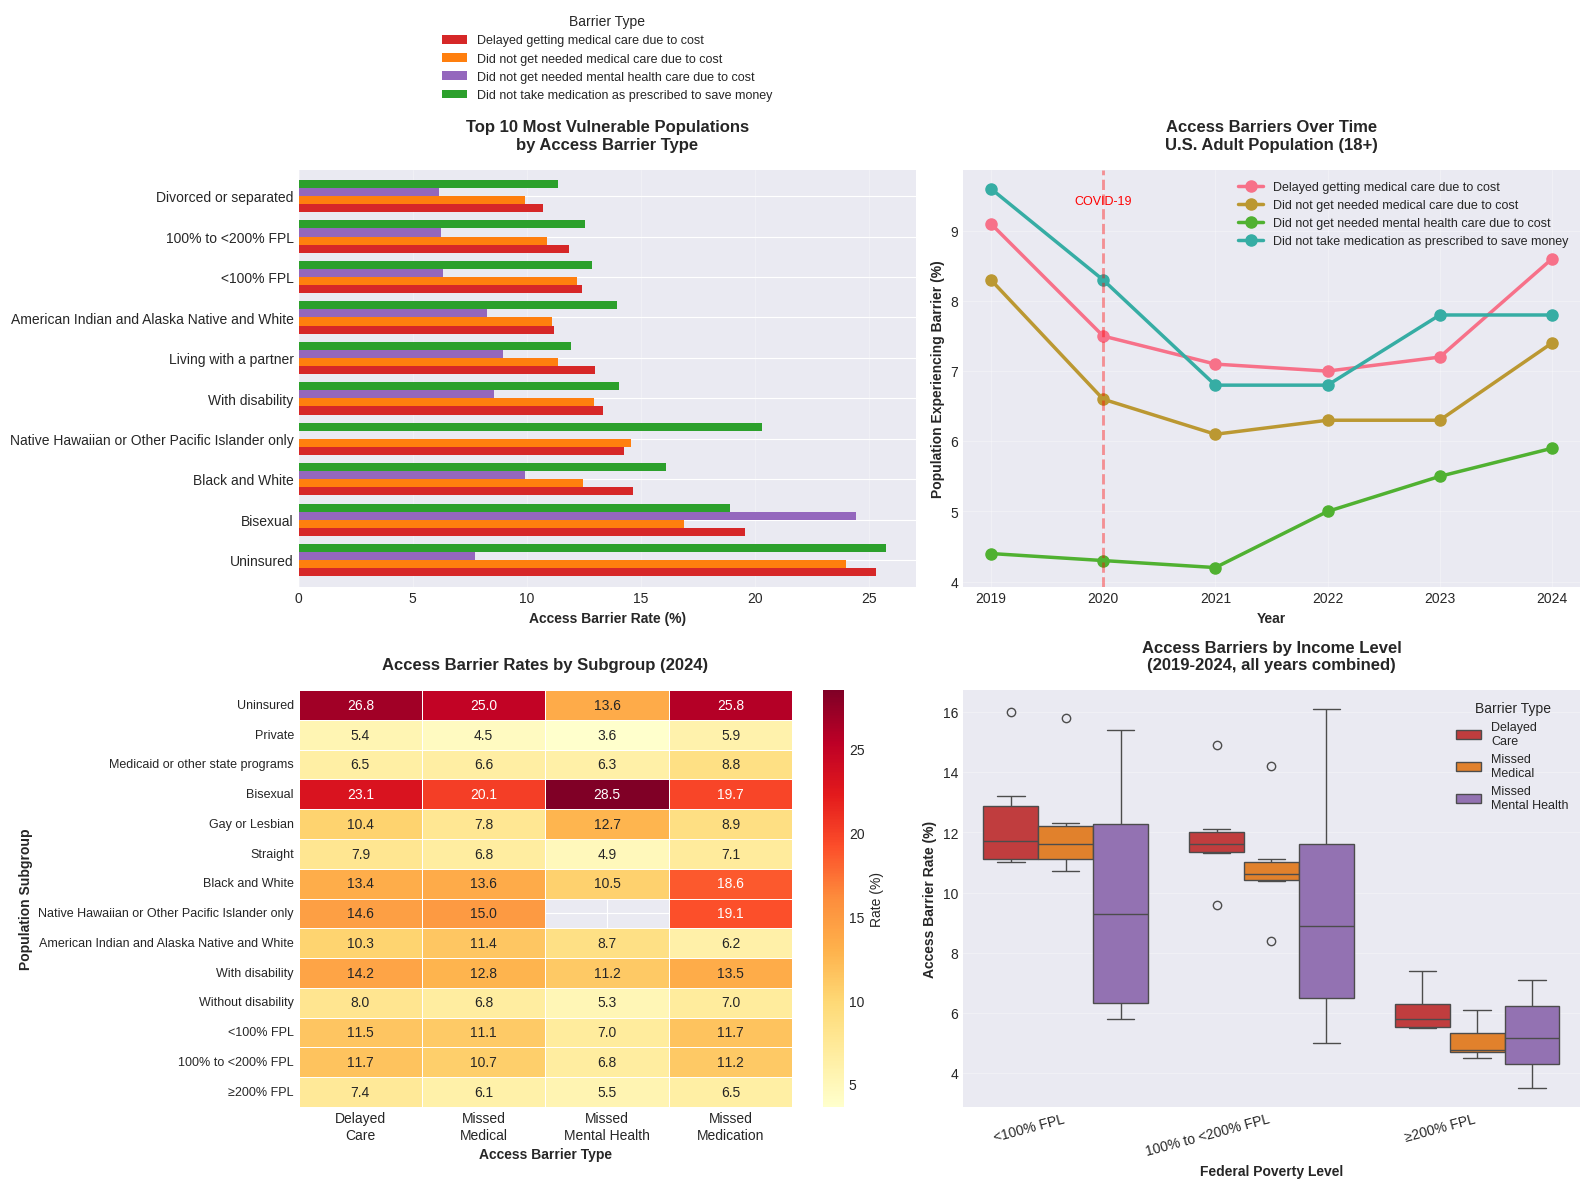

In [13]:
# ----------------------------------------------------------------------------
# Plot 1: Grouped Bar Chart - Top 10 Vulnerable Populations
# ----------------------------------------------------------------------------

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Calculate average rates by subgroup for each barrier
vulnerable_data = []
for topic in access_topics:
    topic_avg = df[df['TOPIC'] == topic].groupby('SUBGROUP')['ESTIMATE'].mean()
    topic_name = topic.replace(' among adults', '')

    for subgroup, rate in topic_avg.items():
        vulnerable_data.append({
            'Barrier': topic_name,
            'Subgroup': subgroup,
            'Rate': rate
        })

df_vulnerable = pd.DataFrame(vulnerable_data)

# Get top 10 overall most vulnerable subgroups
top_10_subgroups = df_vulnerable.groupby('Subgroup')['Rate'].mean().nlargest(10).index

# Plot grouped bar chart
plot_data = df_vulnerable[df_vulnerable['Subgroup'].isin(top_10_subgroups)]
pivot_data = plot_data.pivot(index='Subgroup', columns='Barrier', values='Rate')
pivot_data = pivot_data.reindex(top_10_subgroups)  # Sort by overall vulnerability

pivot_data.plot(kind='barh', ax=axes[0, 0], width=0.8,
                color=['#d62728', '#ff7f0e', '#9467bd', '#2ca02c'])
axes[0, 0].set_xlabel('Access Barrier Rate (%)', fontweight='bold')
axes[0, 0].set_ylabel('')
axes[0, 0].set_title('Top 10 Most Vulnerable Populations\nby Access Barrier Type',
                     fontweight='bold', pad=15)
axes[0, 0].legend(title='Barrier Type', fontsize=9, loc='upper center', bbox_to_anchor=(0.5, 1.4))
axes[0, 0].grid(axis='x', alpha=0.3)

# ----------------------------------------------------------------------------
# Plot 2: Time Series - Trends 2019-2024
# ----------------------------------------------------------------------------
# Use total population only (no demographic breakdowns)
trend_data = df[df['CLASSIFICATION'] == 'Total'].copy()

for topic in access_topics:
    topic_data = trend_data[trend_data['TOPIC'] == topic].groupby('TIME_PERIOD')['ESTIMATE'].mean()
    label = topic.replace(' among adults', '')
    axes[0, 1].plot(topic_data.index, topic_data.values, marker='o',
                   linewidth=2.5, markersize=8, label=label)

axes[0, 1].set_xlabel('Year', fontweight='bold')
axes[0, 1].set_ylabel('Population Experiencing Barrier (%)', fontweight='bold')
axes[0, 1].set_title('Access Barriers Over Time\nU.S. Adult Population (18+)',
                     fontweight='bold', pad=15)
axes[0, 1].legend(fontsize=9, loc='best')
axes[0, 1].grid(alpha=0.3)
axes[0, 1].axvline(x=2020, color='red', linestyle='--', alpha=0.4, linewidth=2)
axes[0, 1].text(2020, axes[0, 1].get_ylim()[1] * 0.95, 'COVID-19',
               color='red', fontsize=9, ha='center')

# ----------------------------------------------------------------------------
# Plot 3: Heatmap - Barriers × Key Subgroups
# ----------------------------------------------------------------------------
# Focus on 2024, socioeconomic + demographic subgroups
key_subgroups = [
    'Uninsured', 'Private', 'Medicaid or other state programs',
    'Bisexual', 'Gay or Lesbian', 'Straight',
    'Black and White', 'Native Hawaiian or Other Pacific Islander only', 'American Indian and Alaska Native and White',
    'With disability', 'Without disability',
    '<100% FPL', '100% to <200% FPL', '≥200% FPL'
]

heatmap_data = df[
    (df['SUBGROUP'].isin(key_subgroups)) &
    (df['TIME_PERIOD'] == 2024)
].pivot_table(
    index='SUBGROUP',
    columns='TOPIC',
    values='ESTIMATE',
    aggfunc='mean'
)

# Reorder to match key_subgroups order
heatmap_data = heatmap_data.reindex([s for s in key_subgroups if s in heatmap_data.index])

# Shorten column names
heatmap_data.columns = ['Delayed\nCare', 'Missed\nMedical', 'Missed\nMental Health', 'Missed\nMedication']

sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='YlOrRd',
           linewidths=0.5, ax=axes[1, 0], cbar_kws={'label': 'Rate (%)'})
axes[1, 0].set_xlabel('Access Barrier Type', fontweight='bold')
axes[1, 0].set_ylabel('Population Subgroup', fontweight='bold')
axes[1, 0].set_title('Access Barrier Rates by Subgroup (2024)',
                    fontweight='bold', pad=15)
axes[1, 0].set_yticklabels(axes[1, 0].get_yticklabels(), rotation=0, fontsize=9)

# ----------------------------------------------------------------------------
# Plot 4: Boxplot - Barriers by Income Level (Single Demographic Dimension)
# ----------------------------------------------------------------------------
# Filter to poverty level subgroups only (mutually exclusive)
poverty_data = df[
    df['GROUP'] == 'Poverty level'
].copy()

# Create abbreviated topic labels
poverty_data['Barrier'] = poverty_data['TOPIC'].apply(
    lambda x: 'Delayed\nCare' if 'Delayed' in x
    else 'Missed\nMedical' if 'medical care' in x
    else 'Missed\nMental Health'
)

sns.boxplot(data=poverty_data, x='SUBGROUP', y='ESTIMATE', hue='Barrier',
           ax=axes[1, 1], palette=['#d62728', '#ff7f0e', '#9467bd'])
axes[1, 1].set_xlabel('Federal Poverty Level', fontweight='bold')
axes[1, 1].set_ylabel('Access Barrier Rate (%)', fontweight='bold')
axes[1, 1].set_title('Access Barriers by Income Level\n(2019-2024, all years combined)',
                    fontweight='bold', pad=15)
axes[1, 1].legend(title='Barrier Type', fontsize=9, loc='upper right')
axes[1, 1].grid(axis='y', alpha=0.3)

# Rotate x-axis labels for readability
plt.setp(axes[1, 1].get_xticklabels(), rotation=15, ha='right')

plt.tight_layout()
plt.show()

## 4. Disparities Snapshot: Race, Insurance, and Income

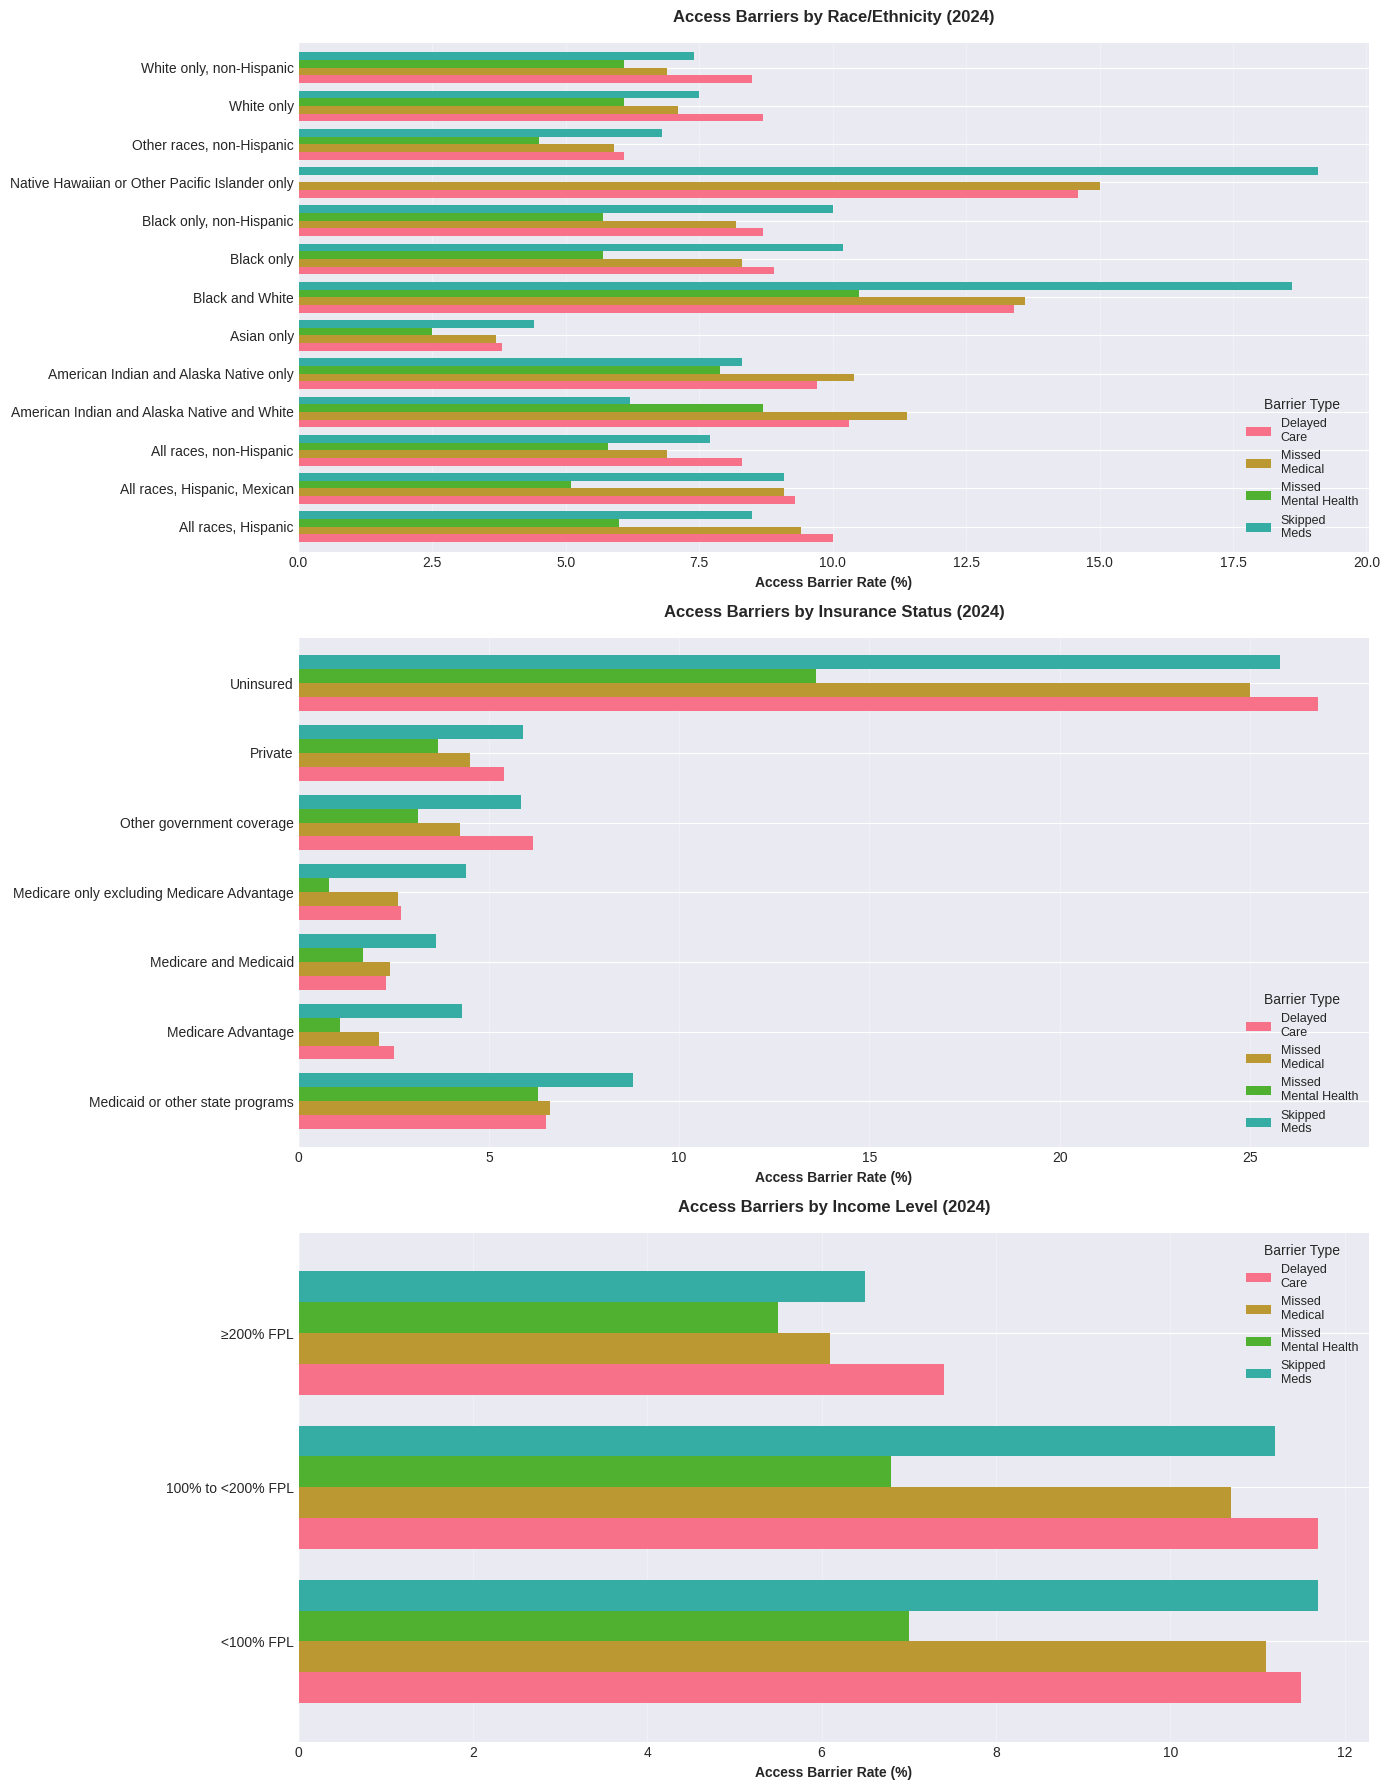

In [14]:
fig, axes = plt.subplots(3, 1, figsize=(14, 18))

# ----------------------------------------------------------------------------
# Panel 1: RACE/ETHNICITY Disparities
# ----------------------------------------------------------------------------
race_data = df[
    (df['GROUP'].str.contains('Race', na=False)) &
    (df['TIME_PERIOD'] == 2024)
]

race_pivot = race_data.pivot_table(
    index='SUBGROUP', columns='TOPIC', values='ESTIMATE', aggfunc='mean'
)
race_pivot.columns = ['Delayed\nCare', 'Missed\nMedical',
                      'Missed\nMental Health', 'Skipped\nMeds']

race_pivot.plot(kind='barh', ax=axes[0], width=0.8)
axes[0].set_xlabel('Access Barrier Rate (%)', fontweight='bold')
axes[0].set_ylabel('')
axes[0].set_title('Access Barriers by Race/Ethnicity (2024)',
                  fontweight='bold', fontsize=12, pad=15)
axes[0].legend(title='Barrier Type', loc='lower right', fontsize=9)
axes[0].grid(axis='x', alpha=0.3)

# ----------------------------------------------------------------------------
# Panel 2: INSURANCE STATUS Disparities
# ----------------------------------------------------------------------------
insurance_data = df[
    (df['GROUP'].str.contains('insurance', case=False, na=False)) &
    (df['TIME_PERIOD'] == 2024)
]

insurance_pivot = insurance_data.pivot_table(
    index='SUBGROUP', columns='TOPIC', values='ESTIMATE', aggfunc='mean'
)
insurance_pivot.columns = ['Delayed\nCare', 'Missed\nMedical',
                           'Missed\nMental Health', 'Skipped\nMeds']

insurance_pivot.plot(kind='barh', ax=axes[1], width=0.8)
axes[1].set_xlabel('Access Barrier Rate (%)', fontweight='bold')
axes[1].set_ylabel('')
axes[1].set_title('Access Barriers by Insurance Status (2024)',
                  fontweight='bold', fontsize=12, pad=15)
axes[1].legend(title='Barrier Type', loc='lower right', fontsize=9)
axes[1].grid(axis='x', alpha=0.3)

# ----------------------------------------------------------------------------
# Panel 3: INCOME LEVEL Disparities
# ----------------------------------------------------------------------------
income_data = df[
    (df['GROUP'] == 'Poverty level') &
    (df['TIME_PERIOD'] == 2024)
]

income_pivot = income_data.pivot_table(
    index='SUBGROUP', columns='TOPIC', values='ESTIMATE', aggfunc='mean'
)
income_pivot.columns = ['Delayed\nCare', 'Missed\nMedical',
                        'Missed\nMental Health', 'Skipped\nMeds']

# Order by poverty level
poverty_order = ['<100% FPL', '100% to <200% FPL', '≥200% FPL']
income_pivot = income_pivot.reindex(poverty_order)

income_pivot.plot(kind='barh', ax=axes[2], width=0.8)
axes[2].set_xlabel('Access Barrier Rate (%)', fontweight='bold')
axes[2].set_ylabel('')
axes[2].set_title('Access Barriers by Income Level (2024)',
                  fontweight='bold', fontsize=12, pad=15)
axes[2].legend(title='Barrier Type', loc='upper right', fontsize=9)
axes[2].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

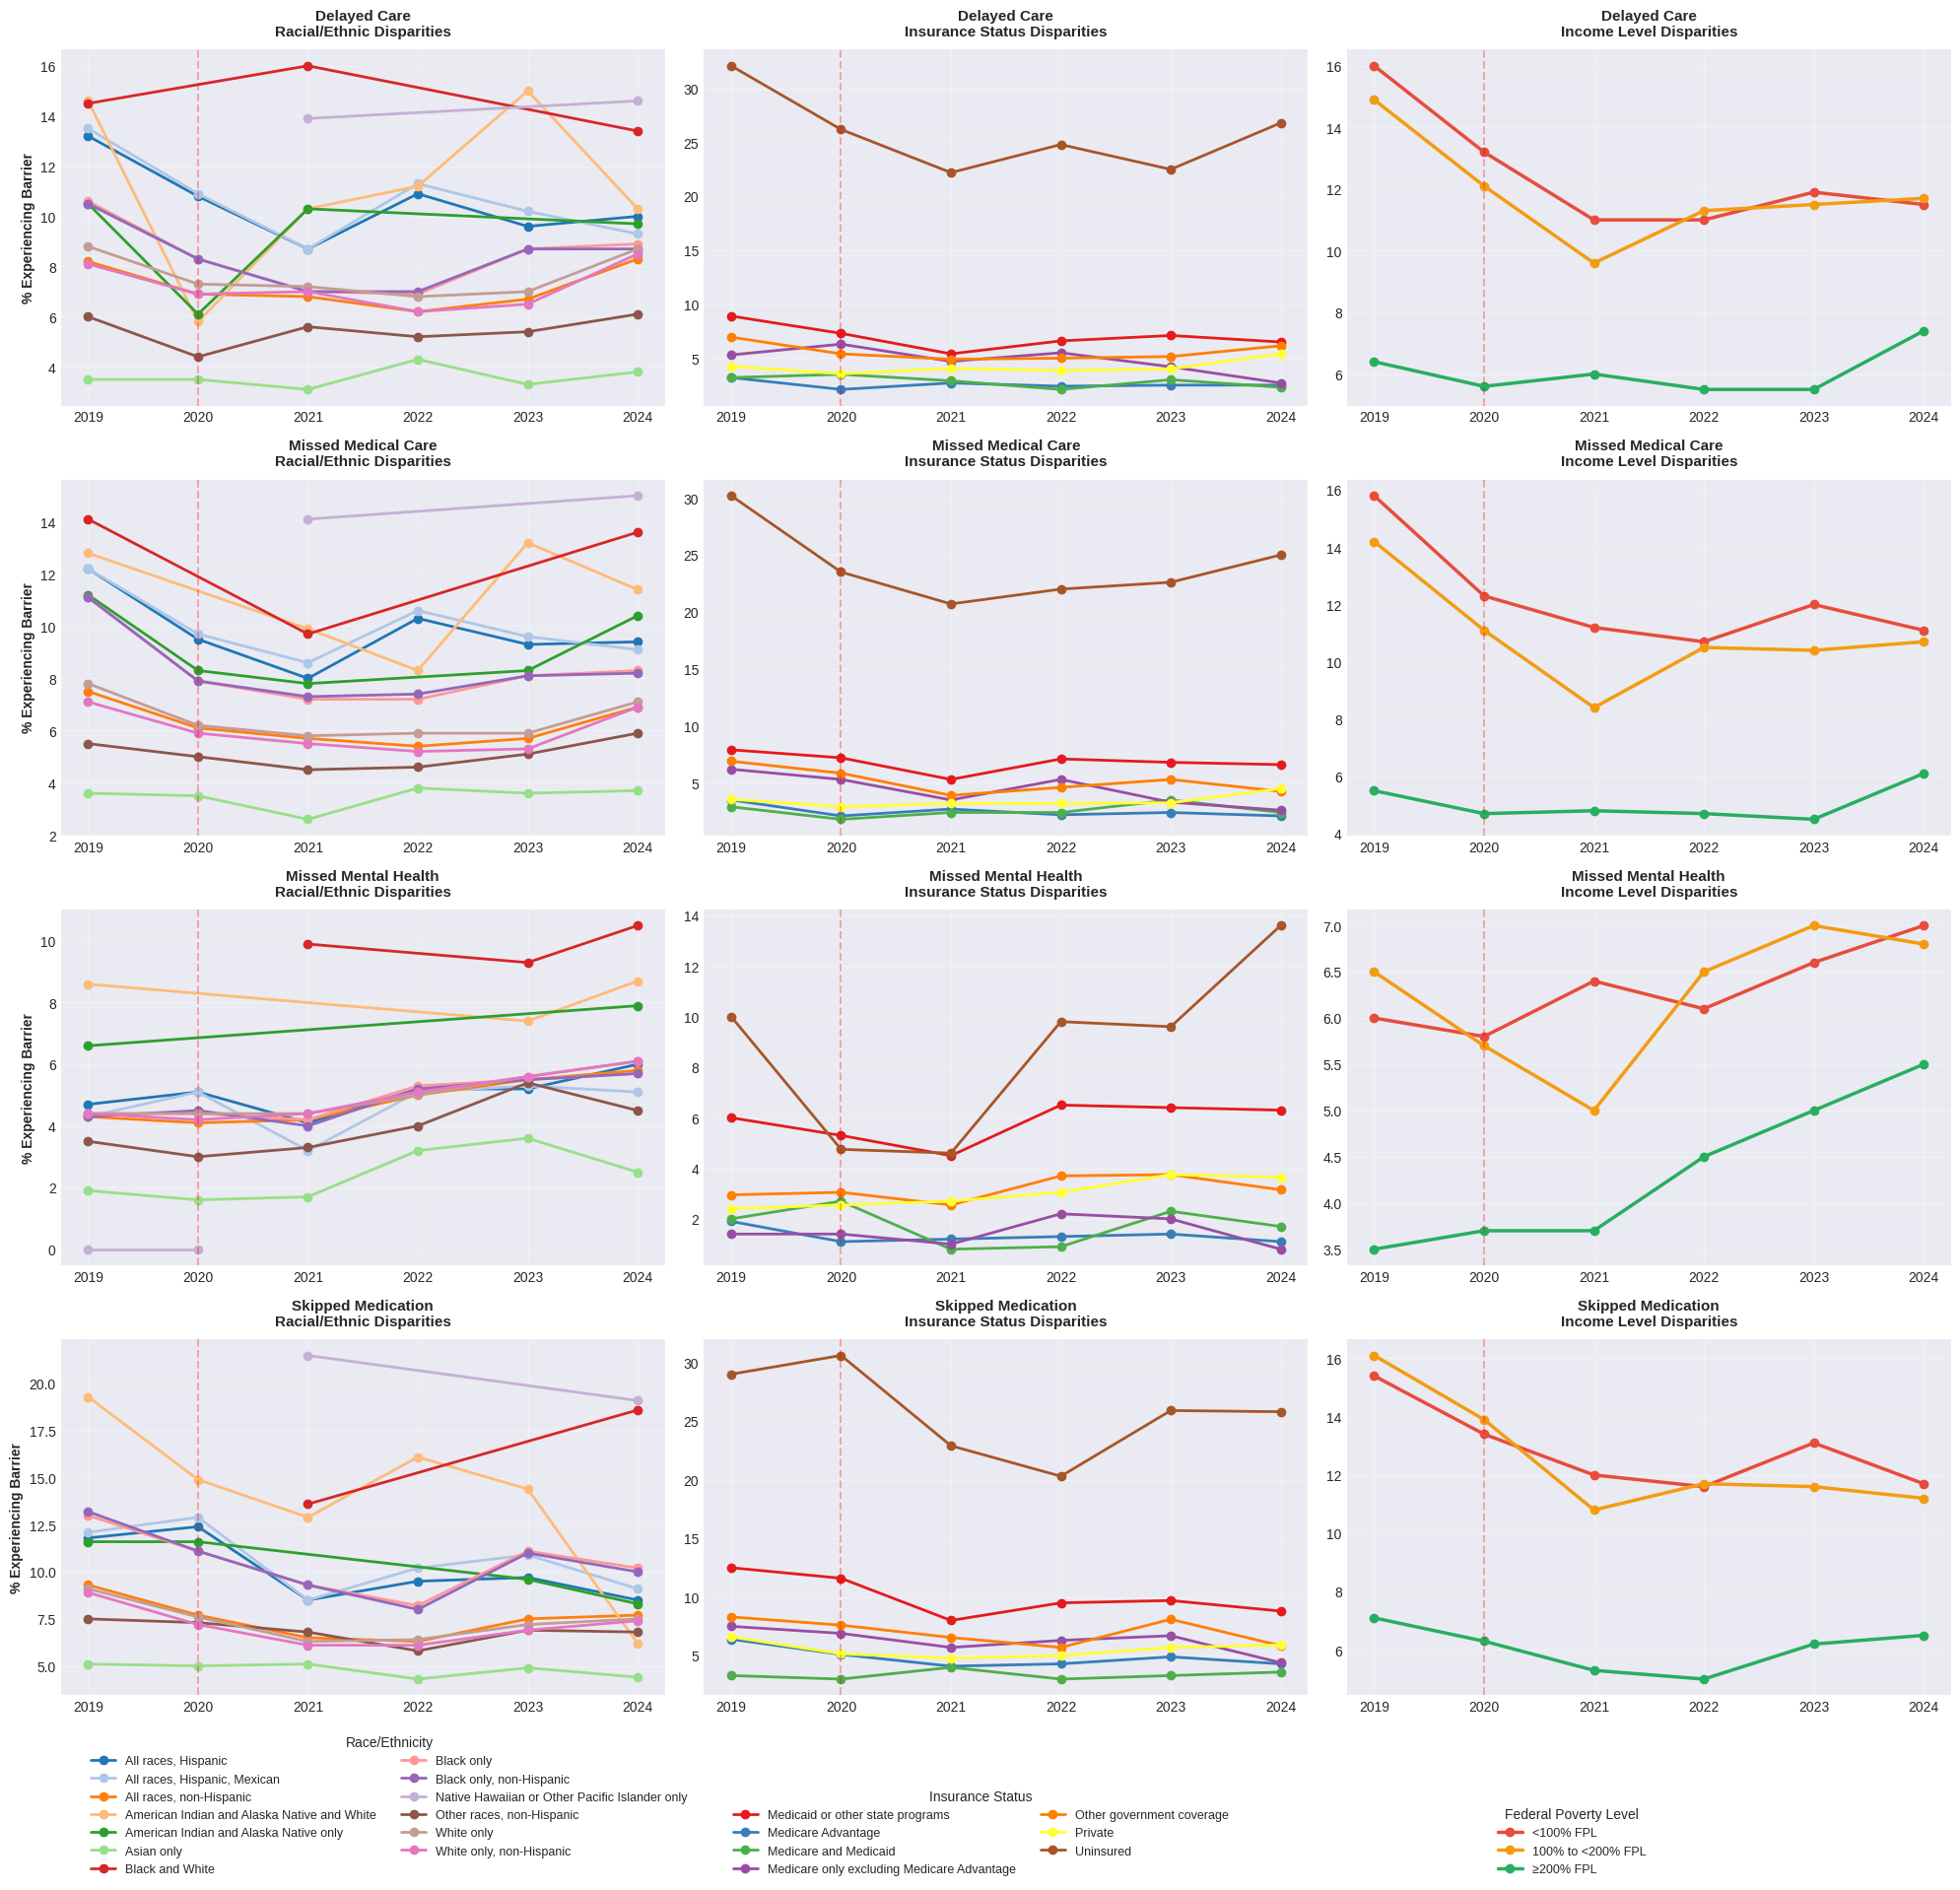

In [15]:
# Barrier names (shortened for titles)
barrier_names = {
    'Delayed getting medical care due to cost among adults': 'Delayed Care',
    'Did not get needed medical care due to cost': 'Missed Medical Care',
    'Did not get needed mental health care due to cost': 'Missed Mental Health',
    'Did not take medication as prescribed to save money': 'Skipped Medication'
}

titles = ['Racial/Ethnic Disparities', 'Insurance Status Disparities', 'Income Level Disparities']

# Pre-define consistent colors
all_race_subs = sorted(df[df['GROUP'].str.contains('Race', na=False)]['SUBGROUP'].unique())
race_color_map = {sub: plt.cm.tab20(i) for i, sub in enumerate(all_race_subs)}

all_ins_subs = sorted(df[df['GROUP'].str.contains('insurance', case=False, na=False)]['SUBGROUP'].unique())
ins_color_map = {sub: plt.cm.Set1(i) for i, sub in enumerate(all_ins_subs)}

poverty_levels = ['<100% FPL', '100% to <200% FPL', '≥200% FPL']
colors_income = ['#e74c3c', '#f39c12', '#27ae60']

fig, axes = plt.subplots(4, 3, figsize=(20, 20))

# Separate handle/label storage for each column
race_handles, ins_handles, inc_handles = {}, {}, {}

for b_idx, (topic, short_name) in enumerate(barrier_names.items()):

    # --- Column 1: RACE ---
    race_data = df[(df['GROUP'].str.contains('Race', na=False)) & (df['TOPIC'] == topic)]
    for race in all_race_subs:
        subset = race_data[race_data['SUBGROUP'] == race].groupby('TIME_PERIOD')['ESTIMATE'].mean()
        if not subset.empty:
            line = axes[b_idx, 0].plot(subset.index, subset.values, marker='o',
                                       color=race_color_map[race], label=race, linewidth=2)
            # Only capture the handle once for the legend
            if race not in race_handles:
                race_handles[race] = line[0]

    # --- Column 2: INSURANCE ---
    ins_data = df[(df['GROUP'].str.contains('insurance', case=False, na=False)) & (df['TOPIC'] == topic)]
    for ins in all_ins_subs:
        subset = ins_data[ins_data['SUBGROUP'] == ins].groupby('TIME_PERIOD')['ESTIMATE'].mean()
        if not subset.empty:
            line = axes[b_idx, 1].plot(subset.index, subset.values, marker='o',
                                       color=ins_color_map[ins], label=ins, linewidth=2)
            if ins not in ins_handles:
                ins_handles[ins] = line[0]

    # --- Column 3: INCOME ---
    inc_data = df[(df['GROUP'] == 'Poverty level') & (df['TOPIC'] == topic)]
    for i, pov in enumerate(poverty_levels):
        subset = inc_data[inc_data['SUBGROUP'] == pov].groupby('TIME_PERIOD')['ESTIMATE'].mean()
        if not subset.empty:
            line = axes[b_idx, 2].plot(subset.index, subset.values, marker='o',
                                       color=colors_income[i], label=pov, linewidth=2.5)
            if pov not in inc_handles:
                inc_handles[pov] = line[0]

    # Formatting
    axes[b_idx, 0].set_ylabel('% Experiencing Barrier', fontweight='bold')
    for c_idx in range(3):
        axes[b_idx, c_idx].grid(alpha=0.3)
        axes[b_idx, c_idx].axvline(x=2020, color='red', linestyle='--', alpha=0.3)
        axes[b_idx, c_idx].set_title(f'{short_name}\n{titles[c_idx]}',
                                      fontweight='bold', fontsize=11, pad=10)

# 2. Clean legends
fig.legend(race_handles.values(), race_handles.keys(),
           loc='lower center', bbox_to_anchor=(0.2, 0.0), ncol=2, title='Race/Ethnicity', fontsize=9)

fig.legend(ins_handles.values(), ins_handles.keys(),
           loc='lower center', bbox_to_anchor=(0.5, 0.0), ncol=2, title='Insurance Status', fontsize=9)

fig.legend(inc_handles.values(), inc_handles.keys(),
           loc='lower center', bbox_to_anchor=(0.8, 0.0), ncol=1, title='Federal Poverty Level', fontsize=9)

plt.tight_layout(rect=[0, 0.08, 1, 0.96])
plt.show()


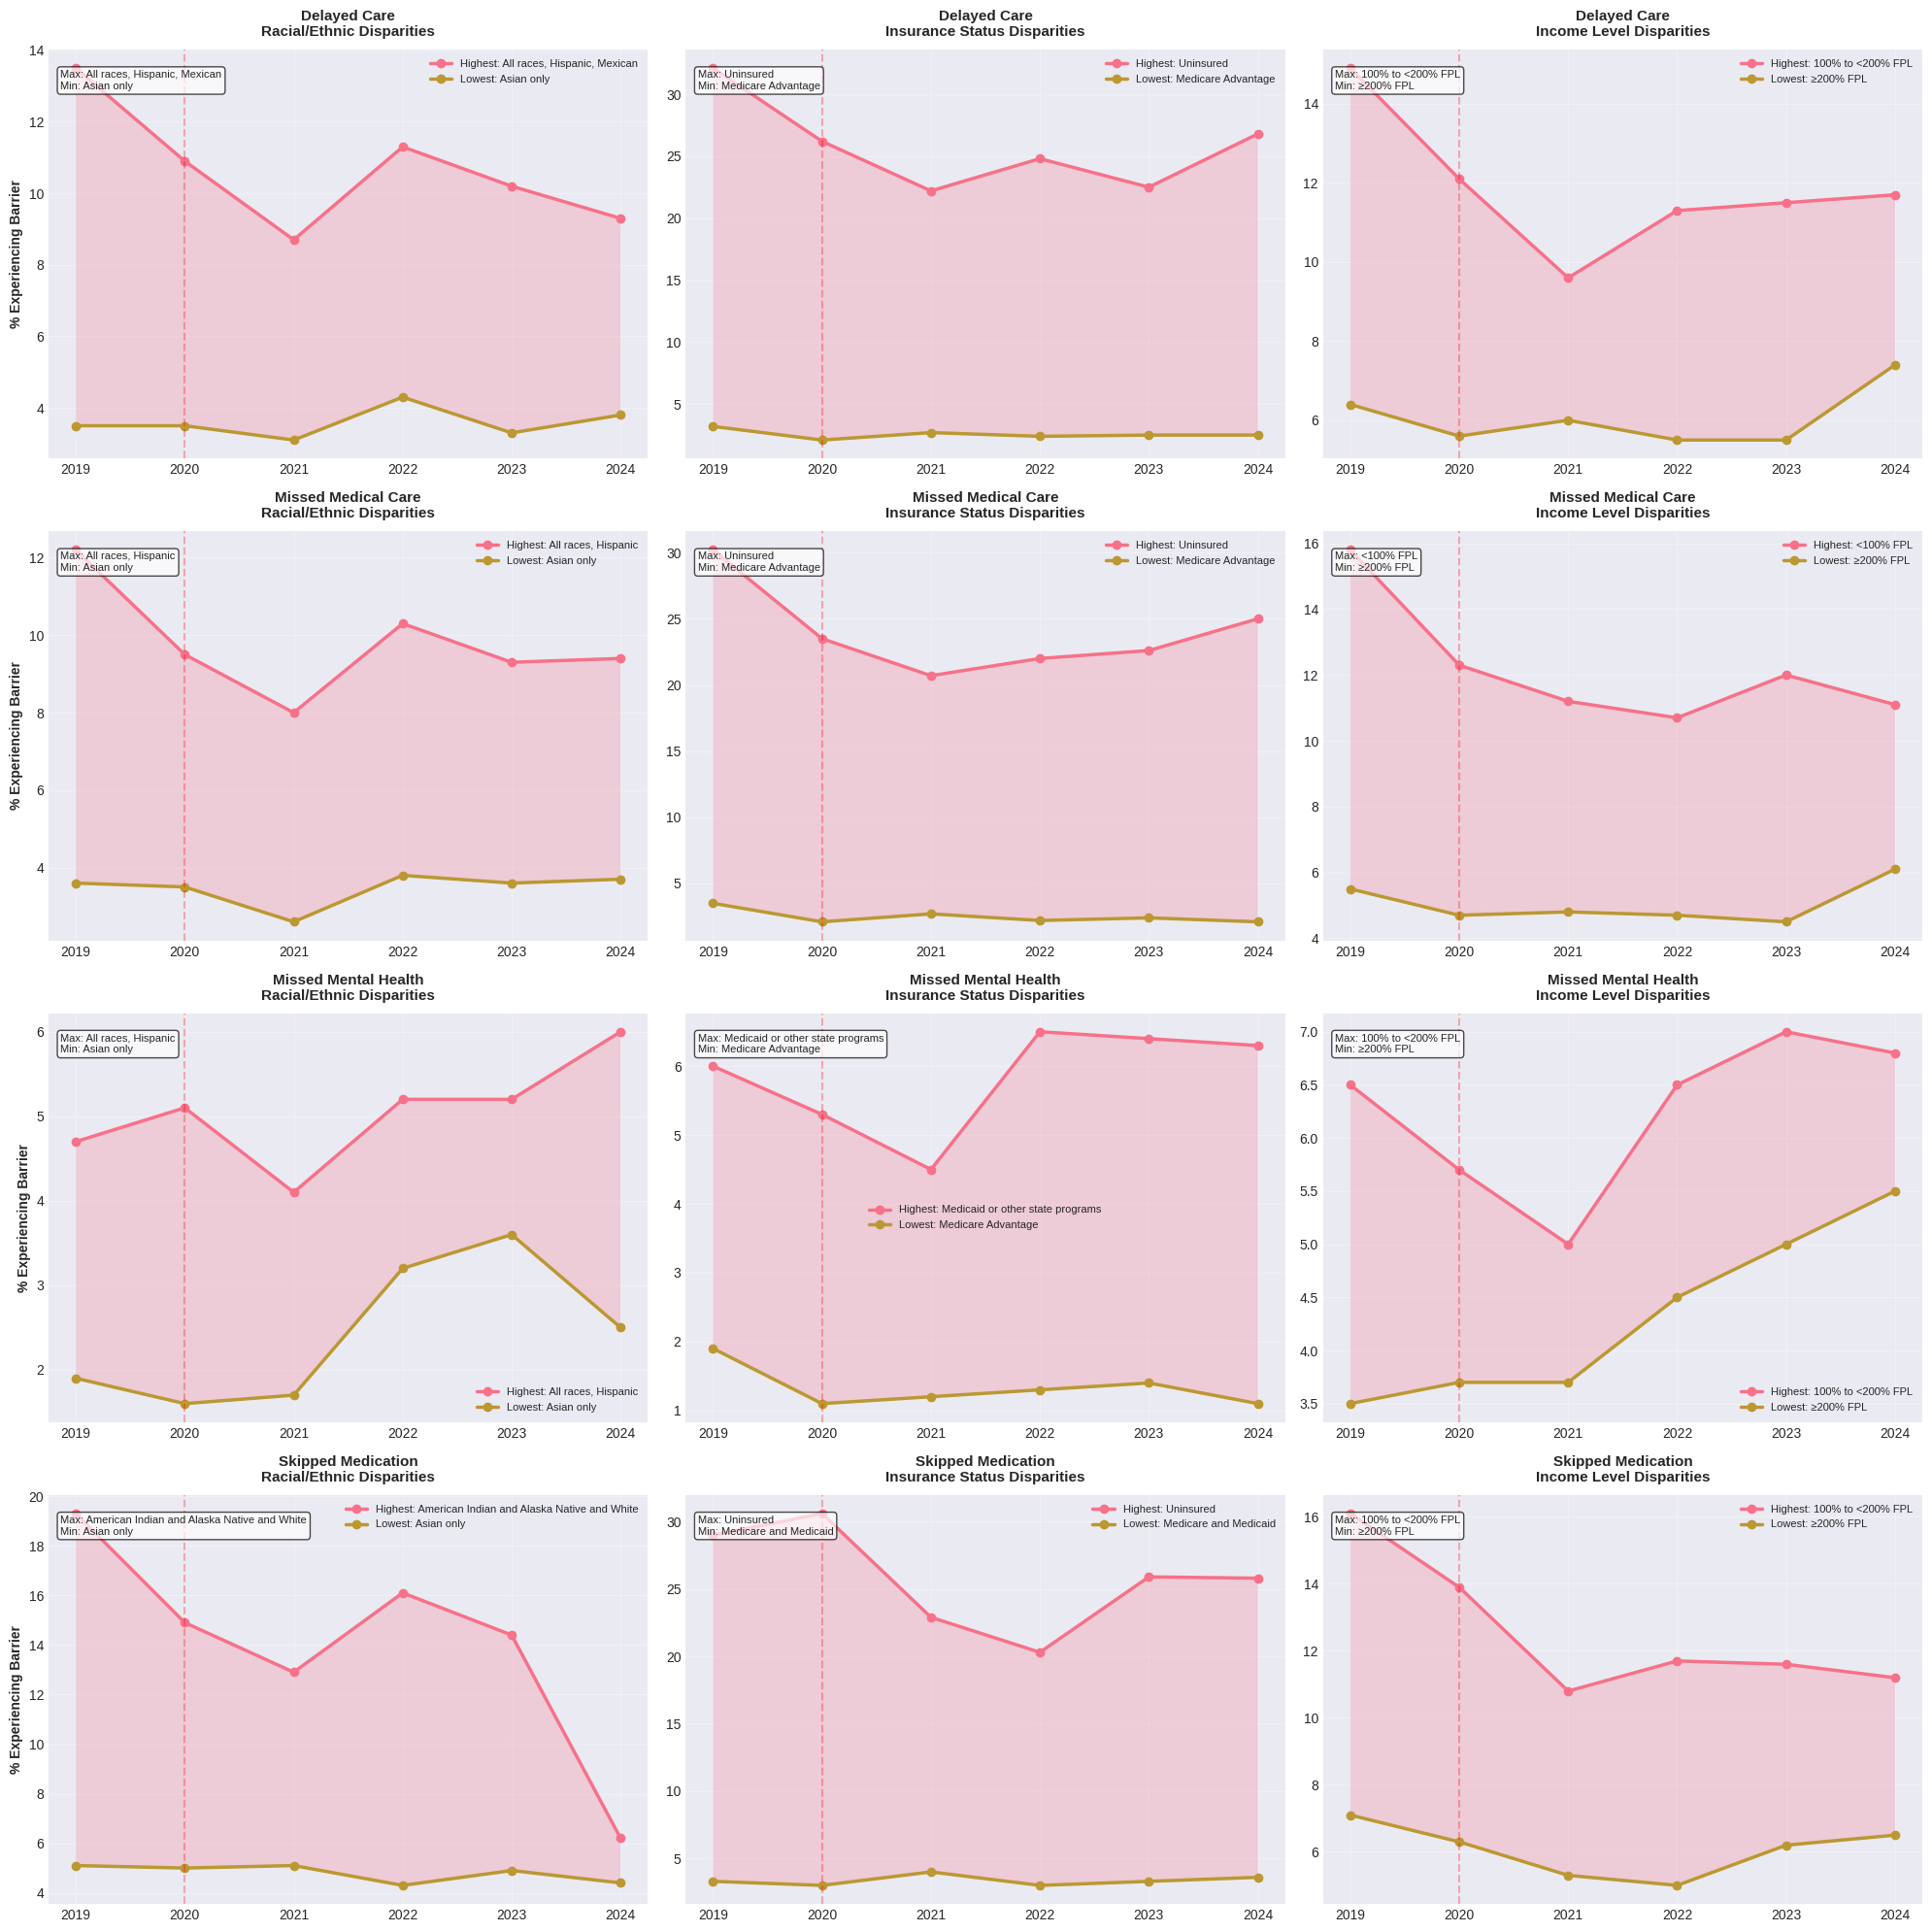

In [16]:
fig, axes = plt.subplots(4, 3, figsize=(20, 20))

# ----------------------------------------------------
# Helper: Keep only subgroups with full year coverage
# ----------------------------------------------------
def filter_complete_subgroups(data, years):

    counts = data.groupby('SUBGROUP')['TIME_PERIOD'].nunique()

    valid_subs = counts[counts == len(years)].index

    return data[data['SUBGROUP'].isin(valid_subs)]


# ----------------------------------------------------
# Helper: Get yearly max/min subgroups
# ----------------------------------------------------
def get_extreme_subgroups(data, years):

    max_groups = []
    min_groups = []

    for y in years:

        yearly = data[data['TIME_PERIOD'] == y]

        means = yearly.groupby('SUBGROUP')['ESTIMATE'].mean()

        max_groups.append(means.idxmax())
        min_groups.append(means.idxmin())

    return list(set(max_groups)), list(set(min_groups))


# ----------------------------------------------------
# Main Plot Loop
# ----------------------------------------------------
for b_idx, (topic, short_name) in enumerate(barrier_names.items()):

    for c_idx, group_type in enumerate(['race', 'insurance', 'income']):

        # ----------------------------
        # Subset by group
        # ----------------------------
        if group_type == 'race':

            data = df[
                (df['GROUP'].str.contains('Race', na=False)) &
                (df['TOPIC'] == topic)
            ]

        elif group_type == 'insurance':

            data = df[
                (df['GROUP'].str.contains('insurance', case=False, na=False)) &
                (df['TOPIC'] == topic)
            ]

        else:  # income

            data = df[
                (df['GROUP'] == 'Poverty level') &
                (df['TOPIC'] == topic)
            ]


        if data.empty:
            continue


        ax = axes[b_idx, c_idx]

        years = sorted(data['TIME_PERIOD'].unique())


        # ----------------------------
        # Keep only full-coverage subgroups
        # ----------------------------
        data = filter_complete_subgroups(data, years)


        if data.empty:
            continue


        # ----------------------------
        # Find yearly extremes
        # ----------------------------
        max_subs, min_subs = get_extreme_subgroups(data, years)


        # Pick most frequent max/min
        max_sub = pd.Series(max_subs).mode()[0]
        min_sub = pd.Series(min_subs).mode()[0]


        # ----------------------------
        # Extract time series
        # ----------------------------
        max_series = (
            data[data['SUBGROUP'] == max_sub]
            .groupby('TIME_PERIOD')['ESTIMATE']
            .mean()
            .reindex(years)
        )

        min_series = (
            data[data['SUBGROUP'] == min_sub]
            .groupby('TIME_PERIOD')['ESTIMATE']
            .mean()
            .reindex(years)
        )


        # ----------------------------
        # Plot
        # ----------------------------
        ax.plot(
            years, max_series,
            marker='o',
            linewidth=2.5,
            label=f'Highest: {max_sub}'
        )

        ax.plot(
            years, min_series,
            marker='o',
            linewidth=2.5,
            label=f'Lowest: {min_sub}'
        )


        # Shade gap
        ax.fill_between(
            years,
            min_series,
            max_series,
            alpha=0.25
        )


        # ----------------------------
        # Labels
        # ----------------------------
        ax.legend(fontsize=8)

        ax.text(
            0.02, 0.95,
            f'Max: {max_sub}\nMin: {min_sub}',
            transform=ax.transAxes,
            fontsize=8,
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.7)
        )


        # ----------------------------
        # Formatting
        # ----------------------------
        ax.grid(alpha=0.3)
        ax.axvline(x=2020, color='red', linestyle='--', alpha=0.3)

        ax.set_title(
            f'{short_name}\n{titles[c_idx]}',
            fontweight='bold',
            fontsize=11,
            pad=10
        )


    axes[b_idx, 0].set_ylabel(
        '% Experiencing Barrier',
        fontweight='bold'
    )


plt.tight_layout()
plt.show()


---
## 5. Feature Engineering

For each (TOPIC, SUBGROUP) time series, we create:
- **lag1, lag2** — Previous 1 and 2 years' ESTIMATE values
- **rolling_mean3** — 3-year rolling average
- **diff1** — Year-over-year change
- **ci_width** — Confidence interval width (proxy for measurement uncertainty; missing values imputed with topic median)

Rows with NaN features (first 2 years of each series) are dropped.

In [17]:
def make_features(data):
    """Engineer lag, trend, and uncertainty features for each time series."""
    data = data.copy()
    g = data.groupby(['TOPIC', 'SUBGROUP'])

    # Lag features
    data['lag1'] = g['ESTIMATE'].shift(1)
    data['lag2'] = g['ESTIMATE'].shift(2)

    # Rolling mean (3-year window)
    data['rolling_mean3'] = g['ESTIMATE'].transform(lambda x: x.shift(1).rolling(3).mean())

    # Year-over-year difference
    data['diff1'] = data['lag1'] - data['lag2']

    # Confidence interval width as uncertainty proxy
    data['ci_width'] = data['ESTIMATE_UCI'] - data['ESTIMATE_LCI']

    # Impute missing ci_width with median for that TOPIC (missing CI bounds → unknown precision, not perfect precision)
    data['ci_width'] = data.groupby('TOPIC')['ci_width'].transform(
        lambda x: x.fillna(x.median())
    )

    return data

df_feat = make_features(df)

# Drop rows where lag features are NaN (first 2 years of each series)
before = len(df_feat)
df_feat = df_feat.dropna(subset=['lag1', 'lag2', 'rolling_mean3', 'diff1'])
print(f"Feature engineering complete: {len(df_feat)} rows ({before - len(df_feat)} dropped due to insufficient history)")
print(f"\nFeature columns: {[c for c in df_feat.columns if c not in df.columns]}")
print(f"Time periods remaining: {sorted(df_feat['TIME_PERIOD'].unique())}")

# Safety: replace any remaining inf values and check
for col in ['diff1', 'ci_width', 'rolling_mean3']:
    df_feat[col] = df_feat[col].replace([np.inf, -np.inf], 0)
print(f"\nInf/NaN check — any inf remaining: {np.isinf(df_feat.select_dtypes(include=np.number)).any().any()}")
print(f"Any NaN remaining: {df_feat[['lag1','lag2','rolling_mean3','diff1','ci_width']].isna().any().any()}")

Feature engineering complete: 913 rows (894 dropped due to insufficient history)

Feature columns: ['lag1', 'lag2', 'rolling_mean3', 'diff1', 'ci_width']
Time periods remaining: [np.int16(2019), np.int16(2020), np.int16(2021), np.int16(2022), np.int16(2023), np.int16(2024)]

Inf/NaN check — any inf remaining: False
Any NaN remaining: False


---
## 6. Categorical Encoding

In [18]:
from sklearn.preprocessing import LabelEncoder

# Store original labels before encoding
label_maps = {}
encoders = {}

for col in ['TOPIC', 'GROUP', 'SUBGROUP']:
    le = LabelEncoder()
    df_feat[col + '_encoded'] = le.fit_transform(df_feat[col])
    encoders[col] = le
    label_maps[col] = dict(zip(le.transform(le.classes_), le.classes_))
    print(f"{col}: {len(le.classes_)} categories")

# Show topic mapping for reference
print("\nTopic encoding:")
for k, v in label_maps['TOPIC'].items():
    print(f"  {k} → {v}")

TOPIC: 4 categories
GROUP: 21 categories
SUBGROUP: 73 categories

Topic encoding:
  0 → Delayed getting medical care due to cost among adults
  1 → Did not get needed medical care due to cost
  2 → Did not get needed mental health care due to cost
  3 → Did not take medication as prescribed to save money


---
## 7. Train/Test Split

**Phase 1 (Validation):** Train ≤ 2023, test on 2024 actuals  
**Phase 2 (Forecasting):** Train ≤ 2024, predict 2025

In [19]:
FEATURES = [
    'TOPIC_encoded',
    'GROUP_encoded',
    'SUBGROUP_encoded',
    'TIME_PERIOD',
    'lag1',
    'lag2',
    'rolling_mean3',
    'diff1',
    'ci_width',
]

TARGET = 'ESTIMATE'

# Phase 1 split
train_mask = df_feat['TIME_PERIOD'] <= 2023
test_mask  = df_feat['TIME_PERIOD'] == 2024

X_train = df_feat.loc[train_mask, FEATURES].copy()
y_train = df_feat.loc[train_mask, TARGET]
X_test  = df_feat.loc[test_mask, FEATURES].copy()
y_test  = df_feat.loc[test_mask, TARGET]

# Assert clean data rather than silently filling
for name, frame in [('X_train', X_train), ('X_test', X_test)]:
    n_inf = np.isinf(frame).sum().sum()
    n_nan = frame.isna().sum().sum()
    assert n_inf == 0 and n_nan == 0, f"{name} has {n_inf} inf and {n_nan} NaN values"
print("Train/test data verified: no NaN or inf values")

print(f"Phase 1 — Validation Split:")
print(f"  Train: {X_train.shape[0]} rows (2019–2023 with valid lags → mostly 2021–2023)")
print(f"  Test:  {X_test.shape[0]} rows (2024)")
print(f"  Features: {len(FEATURES)}")

Train/test data verified: no NaN or inf values
Phase 1 — Validation Split:
  Train: 615 rows (2019–2023 with valid lags → mostly 2021–2023)
  Test:  298 rows (2024)
  Features: 9


---
## 8. Phase 1 — Model Training & Validation (Predict 2024)

We compare three models:
1. **Random Forest** — Robust, handles non-linearity
2. **Gradient Boosting** — Often highest accuracy for tabular data
3. **Ridge Regression** — Simple baseline to check if complexity is warranted

In [39]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

models = {
    'Random Forest': RandomForestRegressor(
        n_estimators=300, max_depth=12, random_state=42, n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingRegressor(
        n_estimators=300, max_depth=6, learning_rate=0.05, random_state=42
    ),
    'Ridge Regression': Ridge(alpha=1.0),
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, pred))
    mae  = mean_absolute_error(y_test, pred)
    r2   = r2_score(y_test, pred)

    # Calculate % of predictions within actual confidence interval
    test_lci = df_feat.loc[test_mask, 'ESTIMATE_LCI'].values
    test_uci = df_feat.loc[test_mask, 'ESTIMATE_UCI'].values
    within_ci = np.mean((pred >= test_lci) & (pred <= test_uci)) * 100

    results[name] = {
        'model': model,
        'predictions': pred,
        'RMSE': rmse,
        'MAE': mae,
        'R²': r2,
        'Within_CI%': within_ci,
    }
    print(f"{name:20s}  RMSE={rmse:.3f}  MAE={mae:.3f}  R²={r2:.4f}  Within CI={within_ci:.1f}%")

Random Forest         RMSE=1.386  MAE=0.920  R²=0.8632  Within CI=60.7%
Gradient Boosting     RMSE=1.361  MAE=0.918  R²=0.8682  Within CI=58.7%
Ridge Regression      RMSE=1.610  MAE=1.253  R²=0.8155  Within CI=43.6%


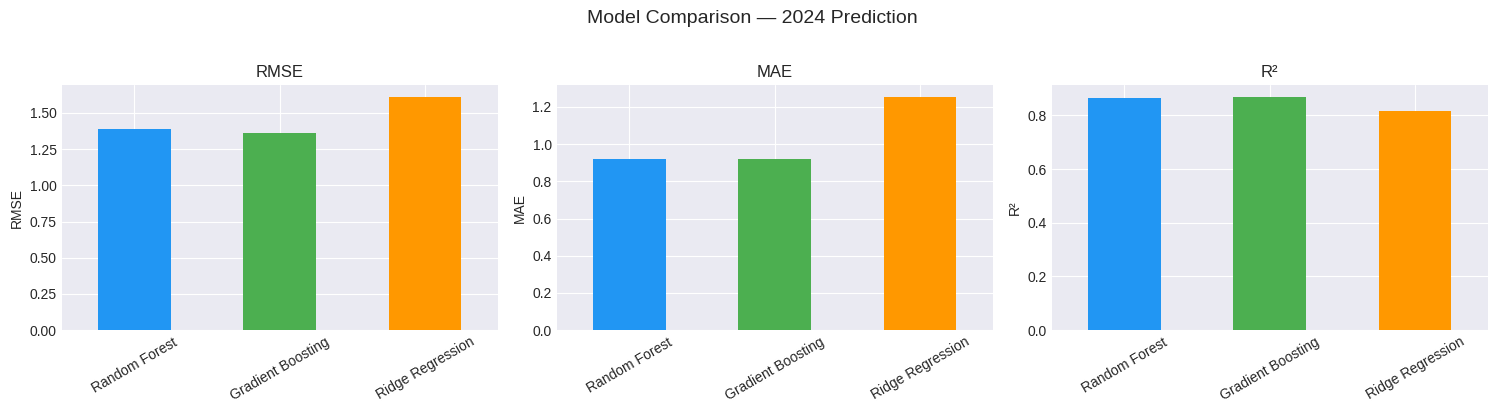


Best model: Gradient Boosting (R²=0.8682)


In [21]:
# Comparison bar chart
metrics_df = pd.DataFrame({
    name: {k: v for k, v in vals.items() if k in ['RMSE', 'MAE', 'R²']}
    for name, vals in results.items()
}).T

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, metric in zip(axes, ['RMSE', 'MAE', 'R²']):
    metrics_df[metric].plot(kind='bar', ax=ax, color=['#2196F3', '#4CAF50', '#FF9800'])
    ax.set_title(metric)
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=30)
fig.suptitle('Model Comparison — 2024 Prediction', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Select best model
best_name = max(results, key=lambda k: results[k]['R²'])
print(f"\nBest model: {best_name} (R²={results[best_name]['R²']:.4f})")

---
## 9. Validation Diagnostics

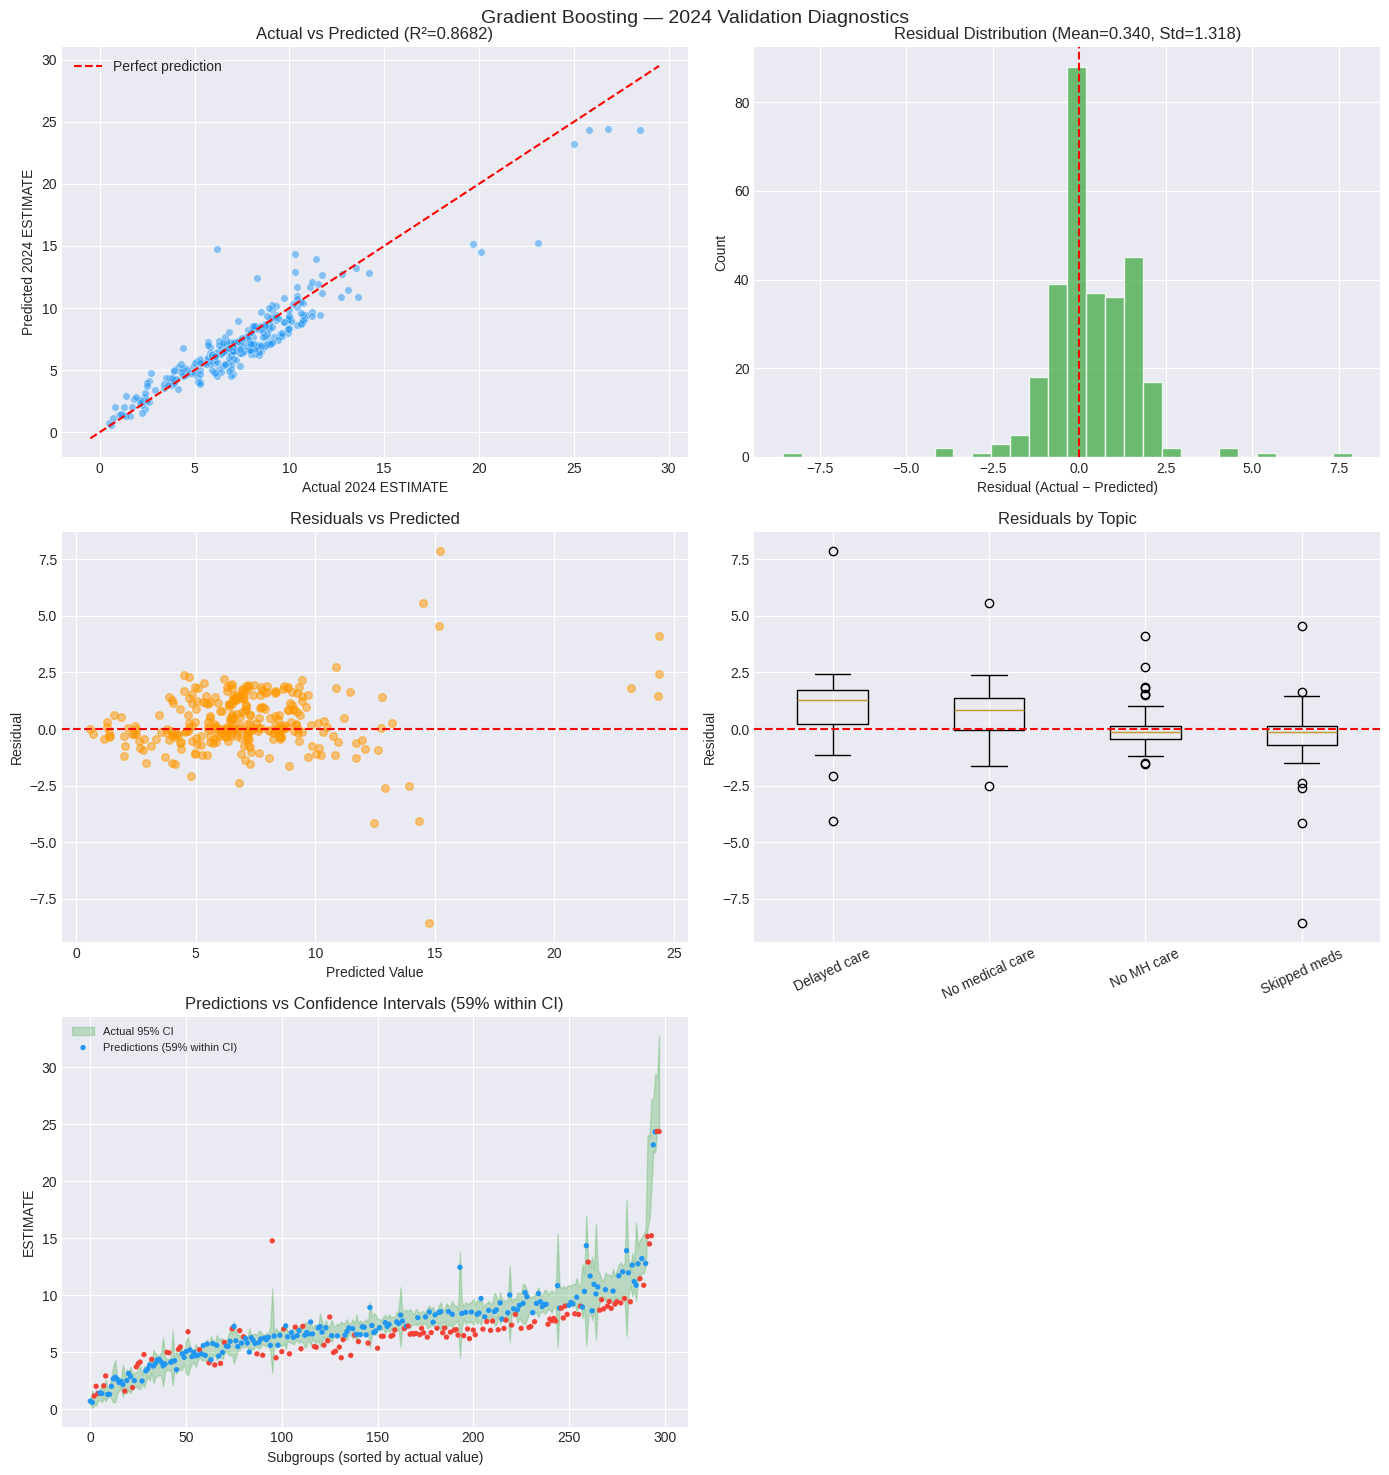


58.7% of predictions fall within the actual 95% CI
  Predictions outside CI: 123 / 298


In [41]:
best = results[best_name]
pred_2024 = best['predictions']
residuals = y_test.values - pred_2024

fig, axes = plt.subplots(3, 2, figsize=(14, 15))

# Actual vs Predicted scatter
ax = axes[0, 0]
ax.scatter(y_test, pred_2024, alpha=0.5, s=30, c='#2196F3', edgecolors='white', linewidth=0.5)
lims = [min(y_test.min(), pred_2024.min()) - 1, max(y_test.max(), pred_2024.max()) + 1]
ax.plot(lims, lims, 'r--', lw=1.5, label='Perfect prediction')
ax.set_xlabel('Actual 2024 ESTIMATE')
ax.set_ylabel('Predicted 2024 ESTIMATE')
ax.set_title(f'Actual vs Predicted (R²={best["R²"]:.4f})')
ax.legend()

# Residual distribution
ax = axes[0, 1]
ax.hist(residuals, bins=30, color='#4CAF50', edgecolor='white', alpha=0.8)
ax.axvline(0, color='red', linestyle='--')
ax.set_xlabel('Residual (Actual − Predicted)')
ax.set_ylabel('Count')
ax.set_title(f'Residual Distribution (Mean={residuals.mean():.3f}, Std={residuals.std():.3f})')

# Residuals vs Predicted
ax = axes[1, 0]
ax.scatter(pred_2024, residuals, alpha=0.5, s=30, c='#FF9800')
ax.axhline(0, color='red', linestyle='--')
ax.set_xlabel('Predicted Value')
ax.set_ylabel('Residual')
ax.set_title('Residuals vs Predicted')

# Residuals by topic
ax = axes[1, 1]
test_with_res = df_feat.loc[test_mask].copy()
test_with_res['residual'] = residuals
topic_residuals = test_with_res.groupby('TOPIC_encoded')['residual'].apply(list)
topic_labels = [encoders['TOPIC'].inverse_transform([t])[0] for t in topic_residuals.index]
# Shorten labels
short_labels = [l.replace('Delayed getting medical care due to cost among adults', 'Delayed care')
                 .replace('Did not get needed medical care due to cost', 'No medical care')
                 .replace('Did not get needed mental health care due to cost', 'No MH care')
                 .replace('Did not take medication as prescribed to save money', 'Skipped meds')
                for l in topic_labels]
ax.boxplot(topic_residuals.values, labels=short_labels)
ax.axhline(0, color='red', linestyle='--')
ax.tick_params(axis='x', rotation=25)
ax.set_ylabel('Residual')
ax.set_title('Residuals by Topic')

# Predictions vs Confidence Intervals
ax = axes[2, 0]
test_lci = df_feat.loc[test_mask, 'ESTIMATE_LCI'].values
test_uci = df_feat.loc[test_mask, 'ESTIMATE_UCI'].values
within = (pred_2024 >= test_lci) & (pred_2024 <= test_uci)
pct_within = within.mean() * 100

# Sort by actual value for readable plot
sort_idx = np.argsort(y_test.values)
x_pos = np.arange(len(sort_idx))
ax.fill_between(x_pos, test_lci[sort_idx], test_uci[sort_idx],
                alpha=0.3, color='#4CAF50', label='Actual 95% CI')
ax.scatter(x_pos, pred_2024[sort_idx], s=8, c=np.where(within[sort_idx], '#2196F3', '#F44336'),
           zorder=3, label=f'Predictions ({pct_within:.0f}% within CI)')
ax.set_xlabel('Subgroups (sorted by actual value)')
ax.set_ylabel('ESTIMATE')
ax.set_title(f'Predictions vs Confidence Intervals ({pct_within:.0f}% within CI)')
ax.legend(fontsize=8)

# Hide unused subplot
axes[2, 1].axis('off')

plt.suptitle(f'{best_name} — 2024 Validation Diagnostics', fontsize=14)
plt.tight_layout()
plt.show()

print(f"\n{pct_within:.1f}% of predictions fall within the actual 95% CI")
print(f"  Predictions outside CI: {(~within).sum()} / {len(within)}")

---
## 10. Model Interpretability

### 10.1 Feature Importance

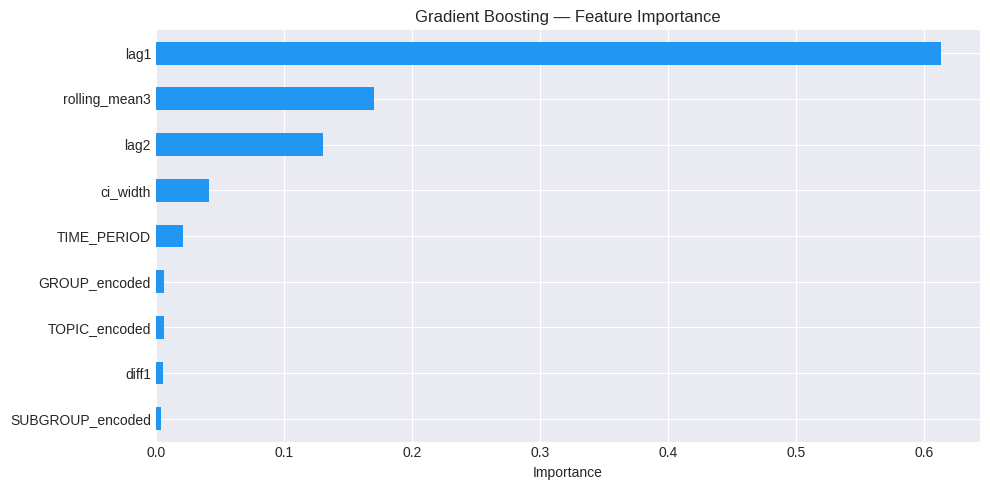

In [23]:
if hasattr(best['model'], 'feature_importances_'):
    importances = pd.Series(best['model'].feature_importances_, index=FEATURES).sort_values()

    fig, ax = plt.subplots(figsize=(10, 5))
    importances.plot(kind='barh', ax=ax, color='#2196F3')
    ax.set_title(f'{best_name} — Feature Importance')
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.show()
else:
    print("(Ridge regression uses coefficients rather than feature_importances_)")
    coefs = pd.Series(best['model'].coef_, index=FEATURES).sort_values()
    coefs.plot(kind='barh')
    plt.title('Ridge Regression Coefficients')
    plt.tight_layout()
    plt.show()

---
### 10.2 SHAP Analysis

Feature importance (above) tells us *which* features matter most globally, but not *how* they push predictions up or down.
SHAP (SHapley Additive exPlanations) decomposes each individual prediction into per-feature contributions,
grounded in cooperative game theory.

We compute SHAP values on the **2024 test set** to understand how the validated model makes its predictions.

**Plots:**
1. **Beeswarm** — Every dot is one prediction; shows direction and magnitude of each feature's effect across all test samples
2. **Bar (mean |SHAP|)** — Global importance ranked by average absolute SHAP contribution
3. **Waterfall (single prediction)** — Step-by-step decomposition of one specific prediction
4. **SHAP Dependence** — How a single feature's value relates to its SHAP contribution (interaction effects)
5. **Decision plot** — Traces how each feature shifts the prediction from the base value for multiple samples
6. **Partial Dependence / ICE** — sklearn's model-agnostic view of marginal feature effects

In [24]:
!pip install shap -q
import shap

# Use TreeExplainer for tree-based models (exact, fast)
# Falls back to KernelExplainer for Ridge
if hasattr(best['model'], 'feature_importances_'):
    explainer = shap.TreeExplainer(best['model'])
    shap_values = explainer.shap_values(X_test)
    print(f"TreeExplainer computed {shap_values.shape[0]} explanations × {shap_values.shape[1]} features")
else:
    explainer = shap.KernelExplainer(best['model'].predict, shap.sample(X_train, 100))
    shap_values = explainer.shap_values(X_test)
    print(f"KernelExplainer computed {shap_values.shape[0]} explanations × {shap_values.shape[1]} features")

base_value = explainer.expected_value
if hasattr(base_value, '__len__'):
    base_value = float(base_value[0]) if len(base_value) == 1 else float(np.mean(base_value))
else:
    base_value = float(base_value)
print(f"Base value (expected prediction): {base_value:.2f}")

TreeExplainer computed 298 explanations × 9 features
Base value (expected prediction): 6.83


#### 10.2.1 Beeswarm Plot

Each dot is one test sample. X-axis = SHAP value (how much that feature pushed the prediction up or down).
Color = feature value (red = high, blue = low). If high feature values consistently push predictions up,
you'll see red dots on the right side.

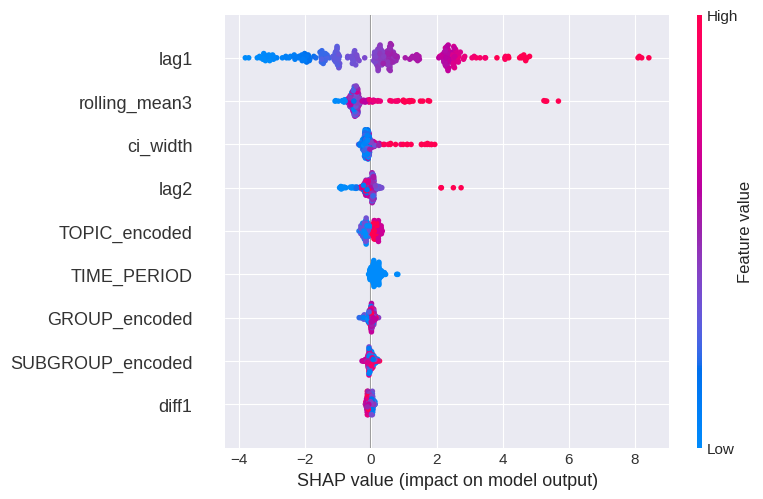

In [25]:
shap.summary_plot(shap_values, X_test, feature_names=FEATURES, show=True)

#### 10.2.2 Mean |SHAP| Bar Plot

Global feature importance measured by average absolute SHAP contribution.
Unlike the built-in `feature_importances_` (which measures impurity reduction),
this directly quantifies how much each feature changes predictions on average.

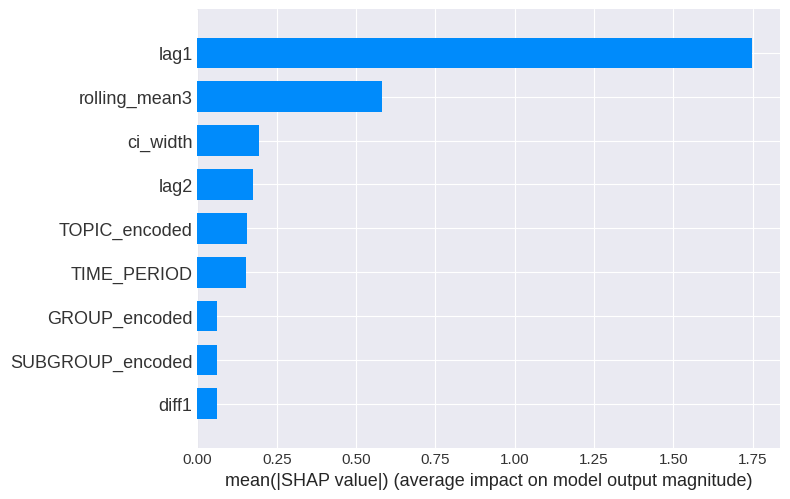

In [26]:
shap.summary_plot(shap_values, X_test, feature_names=FEATURES, plot_type='bar', show=True)

#### 10.2.3 Waterfall Plots — Individual Prediction Decomposition

Waterfall plots show how each feature contributes to push a *single* prediction from the
base value (average prediction) to the final output. We show three examples:
1. The **worst prediction** (largest residual) — to understand where the model struggles
2. The **best prediction** (smallest residual) — to understand what the model gets right
3. A **high-barrier subgroup** — to understand predictions for the most vulnerable populations


Worst prediction (residual=-8.58)
Actual: 6.20  |  Predicted: 14.78
Feature values: {'TOPIC_encoded': np.float64(3.0), 'GROUP_encoded': np.float64(12.0), 'SUBGROUP_encoded': np.float64(14.0), 'TIME_PERIOD': np.float64(2024.0), 'lag1': np.float64(14.399999618530273), 'lag2': np.float64(16.100000381469727), 'rolling_mean3': np.float64(14.466666539510092), 'diff1': np.float64(-1.7000007629394531), 'ci_width': np.float64(7.40000057220459)}


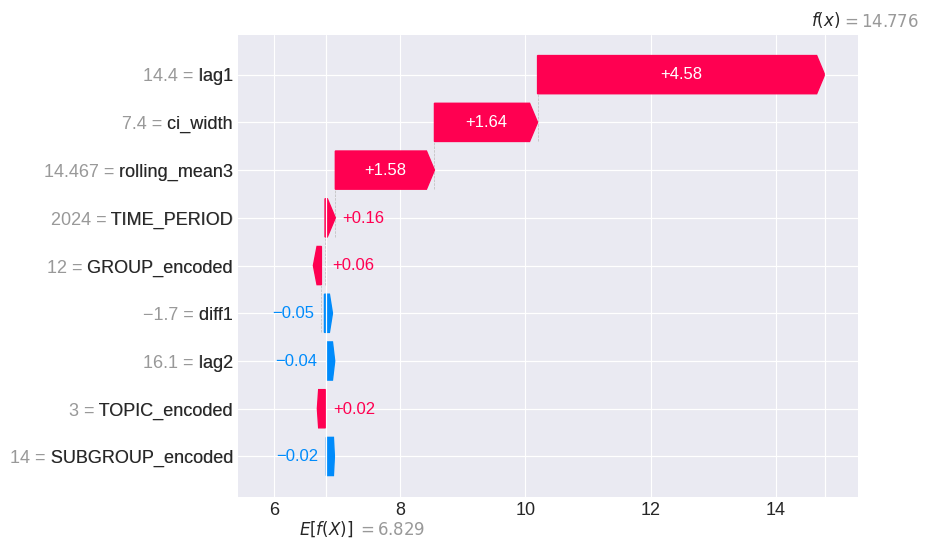


Best prediction (residual=-0.00)
Actual: 5.80  |  Predicted: 5.80
Feature values: {'TOPIC_encoded': np.float64(2.0), 'GROUP_encoded': np.float64(13.0), 'SUBGROUP_encoded': np.float64(13.0), 'TIME_PERIOD': np.float64(2024.0), 'lag1': np.float64(5.5), 'lag2': np.float64(5.0), 'rolling_mean3': np.float64(4.899999936421712), 'diff1': np.float64(0.5), 'ci_width': np.float64(0.6999998092651367)}


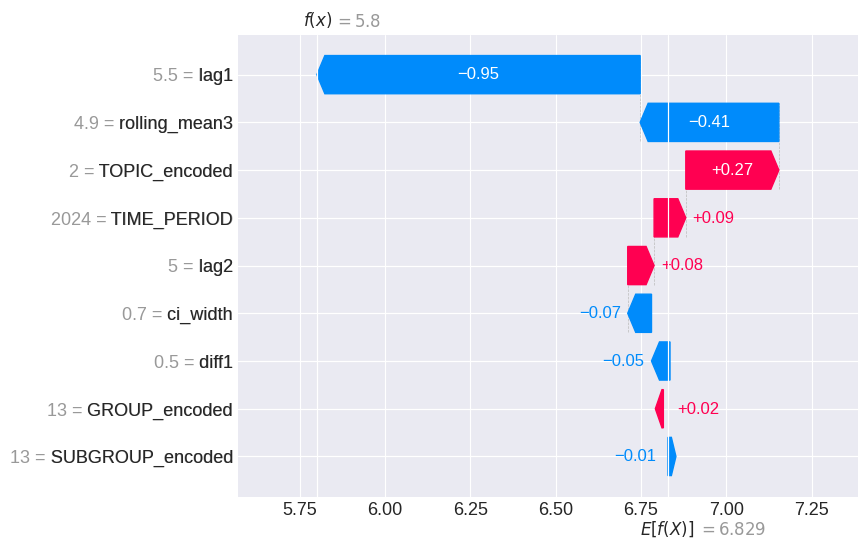


Highest-barrier subgroup (actual=28.5)
Actual: 28.50  |  Predicted: 24.37
Feature values: {'TOPIC_encoded': np.float64(2.0), 'GROUP_encoded': np.float64(16.0), 'SUBGROUP_encoded': np.float64(17.0), 'TIME_PERIOD': np.float64(2024.0), 'lag1': np.float64(26.299999237060547), 'lag2': np.float64(20.700000762939453), 'rolling_mean3': np.float64(23.866666793823242), 'diff1': np.float64(5.599998474121094), 'ci_width': np.float64(8.399999618530273)}


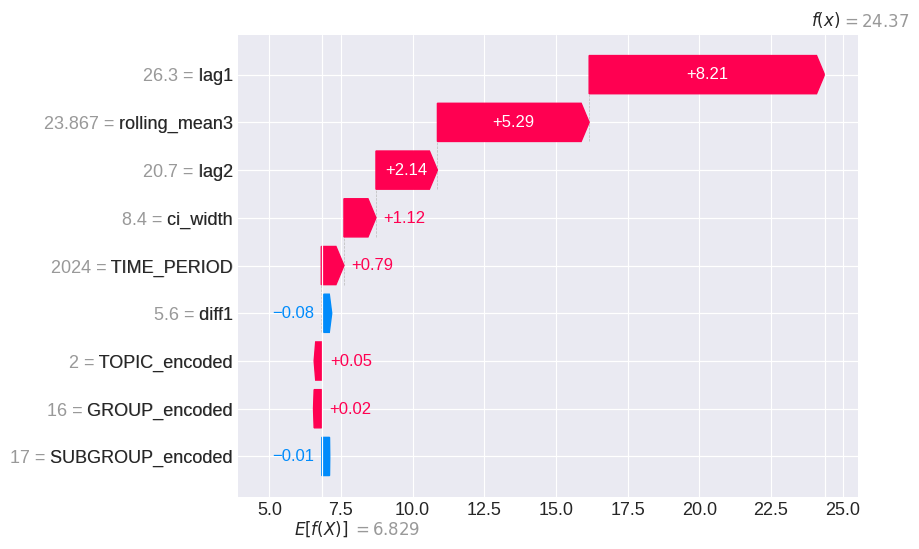

In [27]:
residuals = y_test.values - best['predictions']

# Indices of interest
worst_idx = np.argmax(np.abs(residuals))  # largest error
best_idx = np.argmin(np.abs(residuals))    # smallest error
high_barrier_idx = np.argmax(y_test.values) # highest actual value

cases = {
    f'Worst prediction (residual={residuals[worst_idx]:.2f})': worst_idx,
    f'Best prediction (residual={residuals[best_idx]:.2f})': best_idx,
    f'Highest-barrier subgroup (actual={y_test.values[high_barrier_idx]:.1f})': high_barrier_idx,
}

for title, idx in cases.items():
    print(f"\n{'='*60}")
    print(f"{title}")
    print(f"Actual: {y_test.values[idx]:.2f}  |  Predicted: {best['predictions'][idx]:.2f}")
    print(f"Feature values: {dict(zip(FEATURES, X_test.iloc[idx].values))}")
    print(f"{'='*60}")

    explanation = shap.Explanation(
        values=shap_values[idx],
        base_values=explainer.expected_value,
        data=X_test.iloc[idx].values,
        feature_names=FEATURES
    )
    shap.plots.waterfall(explanation, show=True)

#### 10.2.4 SHAP Dependence Plots

Shows the relationship between a feature's *value* (x-axis) and its *SHAP contribution* (y-axis).
SHAP automatically selects an interaction feature for coloring, revealing interaction effects.
For example, if `lag1` has a different effect depending on `ci_width`, the colors will separate.

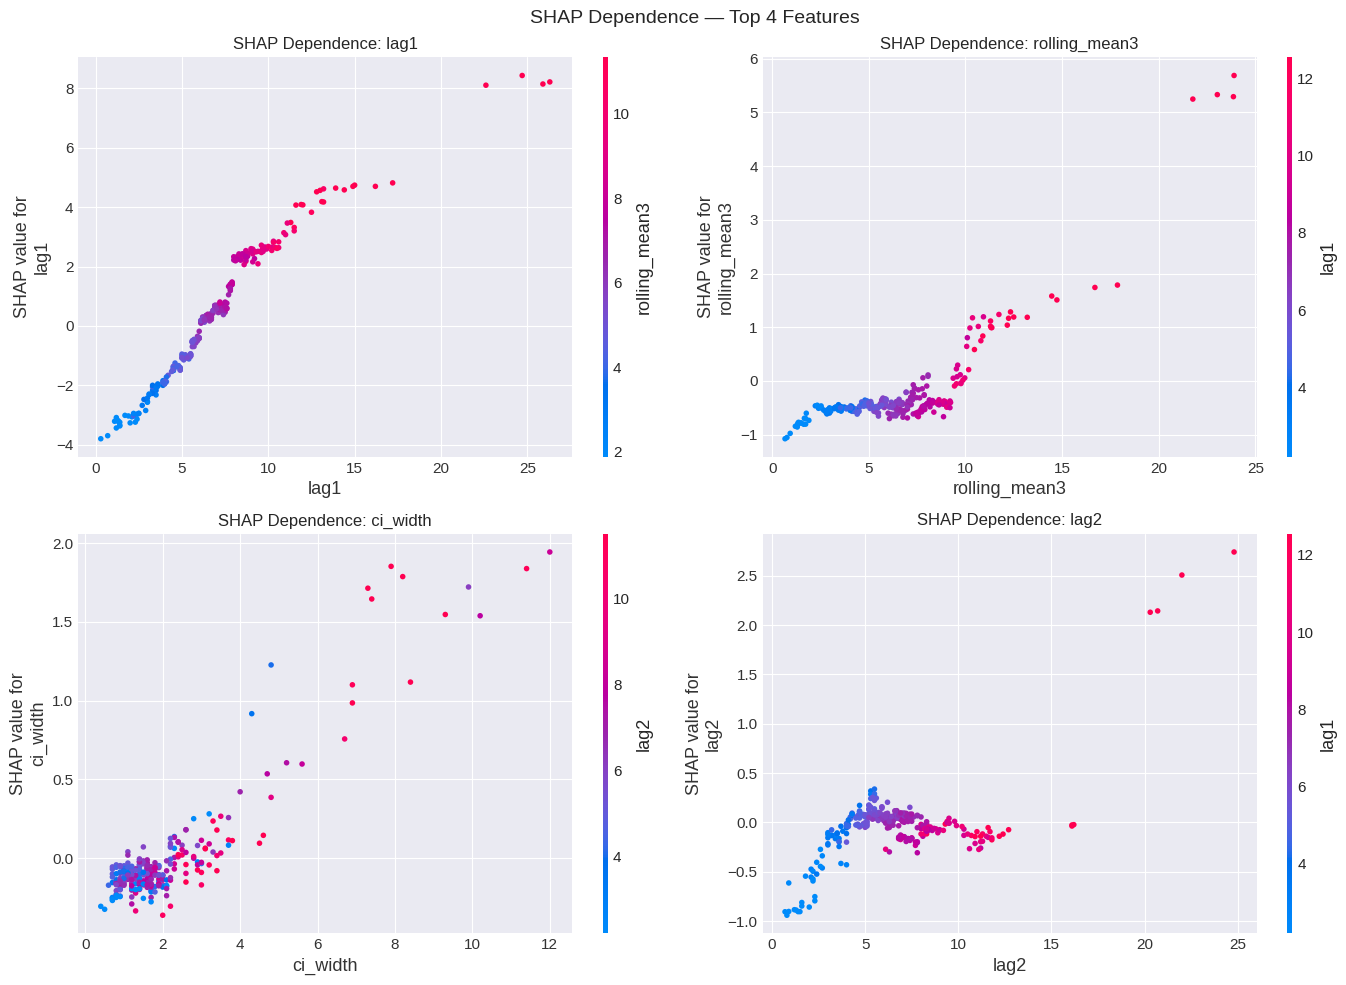

In [28]:
# Dependence plots for top 4 features by importance
top_features = pd.Series(
    np.abs(shap_values).mean(axis=0), index=FEATURES
).sort_values(ascending=False).head(4).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, feat in zip(axes.flat, top_features):
    feat_idx = FEATURES.index(feat)
    shap.dependence_plot(
        feat_idx, shap_values, X_test,
        feature_names=FEATURES, ax=ax, show=False
    )
    ax.set_title(f'SHAP Dependence: {feat}')
plt.suptitle('SHAP Dependence — Top 4 Features', fontsize=14)
plt.tight_layout()
plt.show()

#### 10.2.5 Subgroup Deep Dive — SHAP for Policy-Relevant Populations

We pick specific high-interest subgroups (uninsured, low-income, racial minorities)
and show how the model constructs their predictions differently.


Uninsured — Delayed Care
Actual: 26.8  |  Predicted: 24.4  |  Error: +2.41


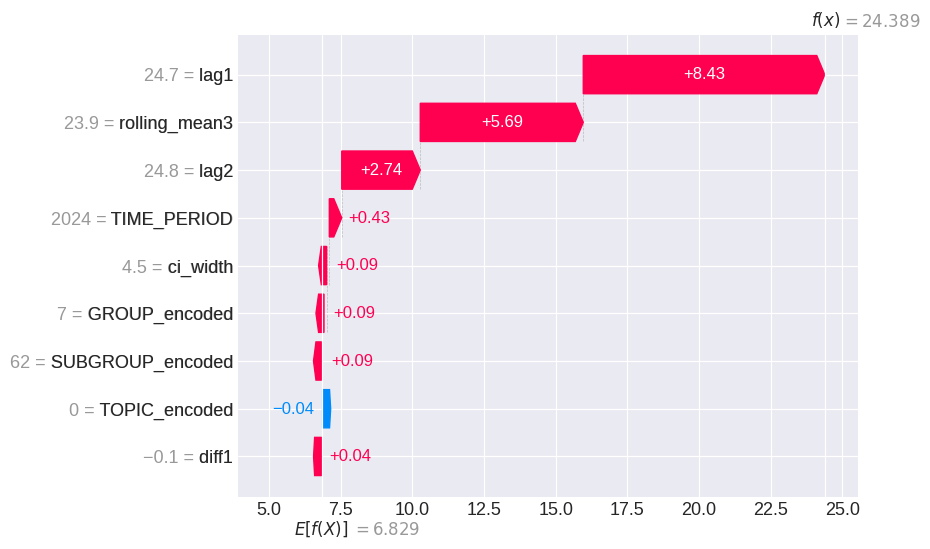


Uninsured — No Med Care
Actual: 25.0  |  Predicted: 23.2  |  Error: +1.80


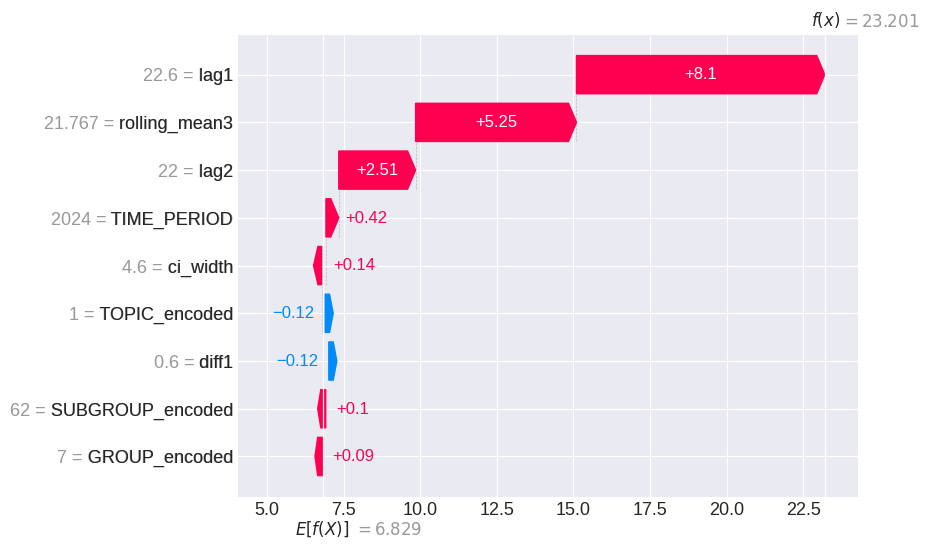


Uninsured — No MH Care
Actual: 13.6  |  Predicted: 10.9  |  Error: +2.73


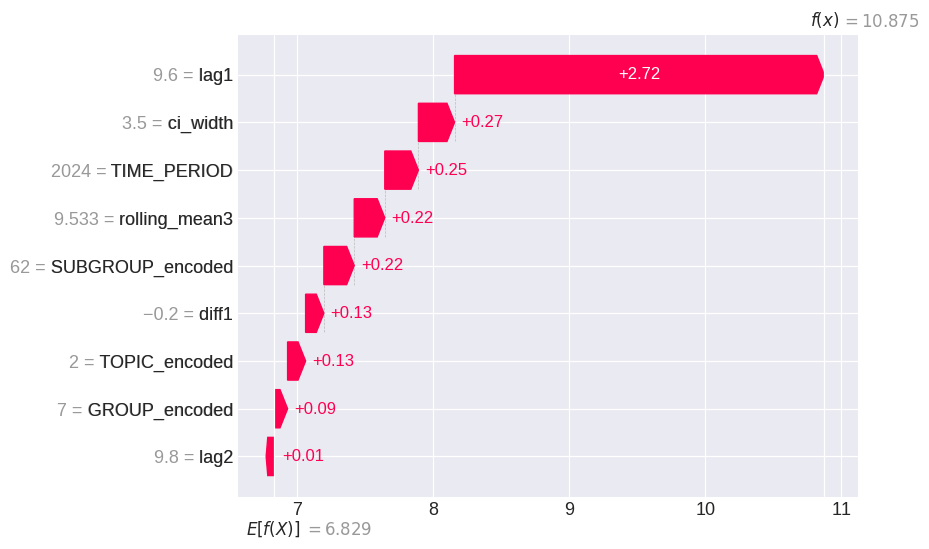


Uninsured — Skipped Meds
Actual: 25.8  |  Predicted: 24.4  |  Error: +1.45


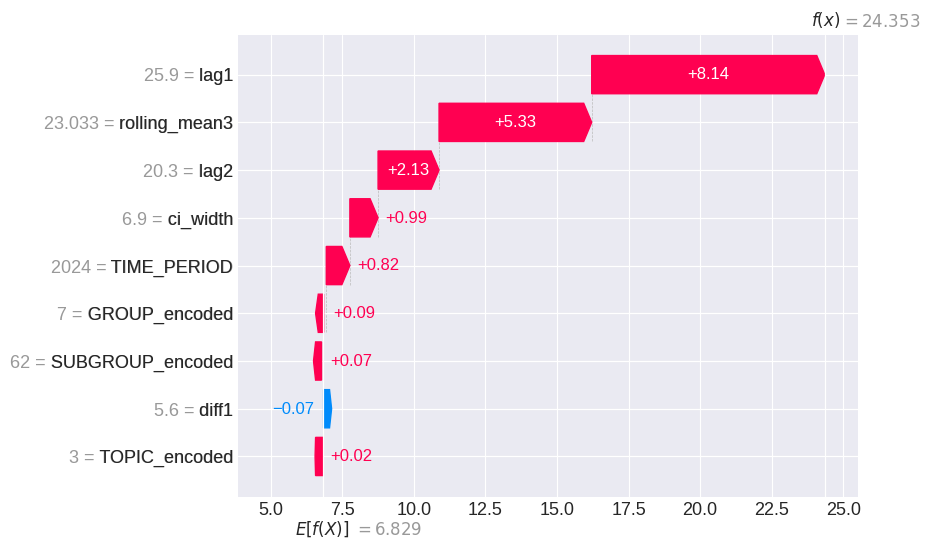


Black only — Delayed Care
Actual: 8.9  |  Predicted: 8.7  |  Error: +0.19


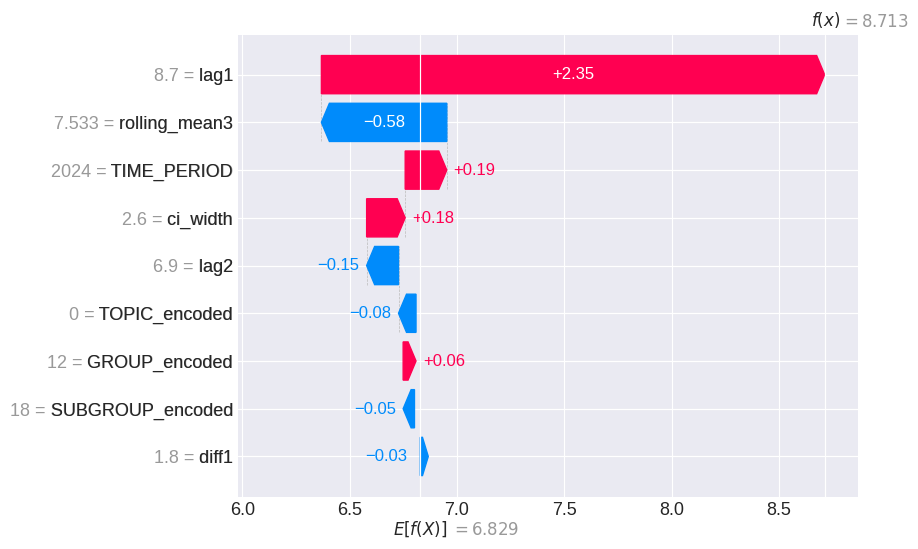


Black only — No Med Care
Actual: 8.3  |  Predicted: 8.3  |  Error: -0.03


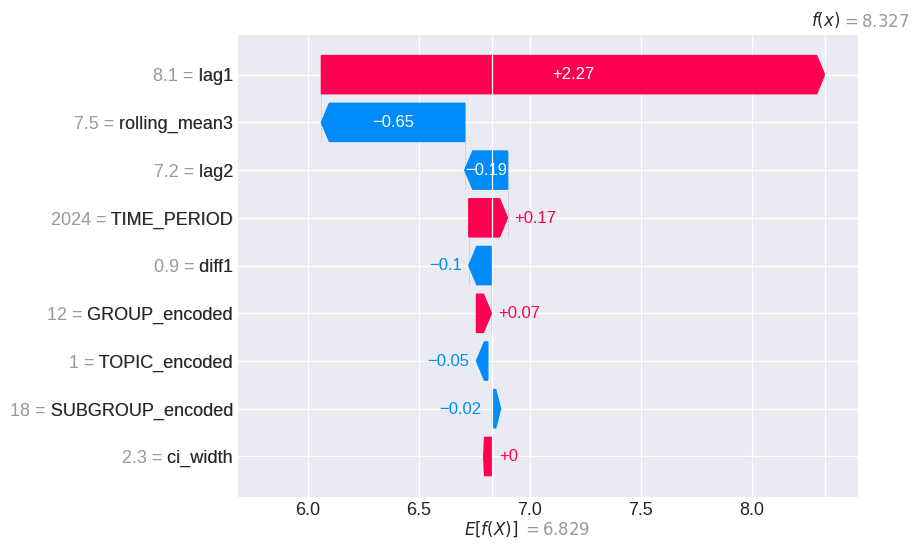

In [29]:
# Identify policy-relevant subgroups in the test set
test_df = df_feat.loc[test_mask].copy()
test_df['shap_sum'] = shap_values.sum(axis=1)
test_df['predicted'] = best['predictions']

# Subgroups of interest
interest_subgroups = ['Uninsured', 'Hispanic', 'Black only', '<100% FPL',
                      '18 years and older', 'With disability']

found = []
for sg in interest_subgroups:
    mask = test_df['SUBGROUP'] == sg
    if mask.any():
        indices = test_df.index[mask]
        # Get position in X_test (integer location)
        for orig_idx in indices:
            pos = X_test.index.get_loc(orig_idx)
            topic_encoded = test_df.loc[orig_idx, 'TOPIC_encoded']
            topic_name = encoders['TOPIC'].inverse_transform([int(topic_encoded)])[0]
            # Shorten topic name
            short_topic = topic_name.replace('Delayed getting medical care due to cost among adults', 'Delayed Care')
            short_topic = short_topic.replace('Did not get needed medical care due to cost', 'No Med Care')
            short_topic = short_topic.replace('Did not get needed mental health care due to cost', 'No MH Care')
            short_topic = short_topic.replace('Did not take medication as prescribed to save money', 'Skipped Meds')
            found.append((f'{sg} — {short_topic}', pos, orig_idx))

# Show waterfall for up to 6 of these
for label, pos, orig_idx in found[:6]:
    actual = y_test.values[pos]
    pred = best['predictions'][pos]
    print(f"\n{'='*60}")
    print(f"{label}")
    print(f"Actual: {actual:.1f}  |  Predicted: {pred:.1f}  |  Error: {actual - pred:+.2f}")
    print(f"{'='*60}")

    explanation = shap.Explanation(
        values=shap_values[pos],
        base_values=base_value,
        data=X_test.iloc[pos].values,
        feature_names=FEATURES
    )
    shap.plots.waterfall(explanation, show=True)

### 10.3 Decision Plot

Each line traces one prediction from the base value (left) through cumulative feature contributions
to the final prediction (right). Lines that diverge sharply show where specific features cause
unusual predictions. Outlier lines often correspond to the subgroups the model struggles with.

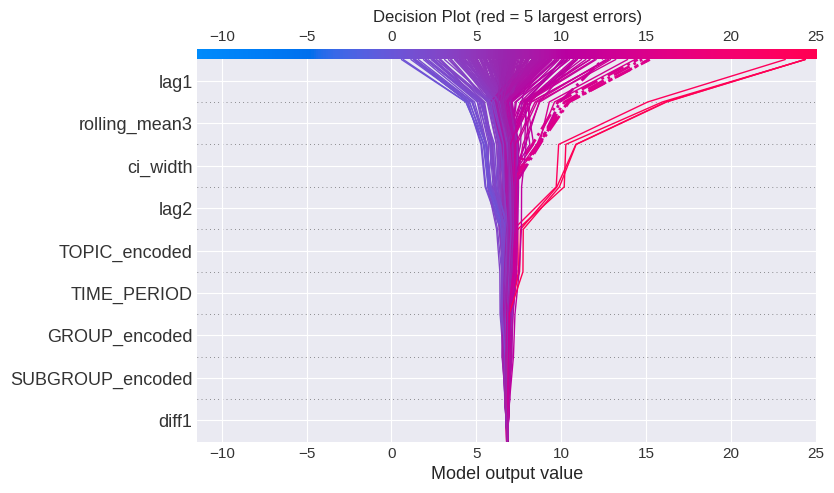

In [30]:
# Decision plot for all test samples, highlighting the 5 largest errors
residuals = y_test.values - best['predictions']
top5_worst = np.argsort(np.abs(residuals))[-5:]

# Create highlight mask
highlight = np.full(len(X_test), False)
highlight[top5_worst] = True

shap.decision_plot(
    base_value, shap_values, X_test,
    feature_names=FEATURES,
    highlight=highlight,
    title='Decision Plot (red = 5 largest errors)'
)
plt.show()

### 10.4 Partial Dependence & ICE Plots (Model-Agnostic)

Unlike SHAP (which explains the model's learned behavior), Partial Dependence Plots (PDP)
show the **marginal effect** of a feature by averaging predictions over all other feature values.
Individual Conditional Expectation (ICE) curves show the same thing per-sample, revealing heterogeneity.

If ICE lines are parallel, the feature effect is consistent across subgroups.
If they cross or diverge, the feature interacts with other variables.

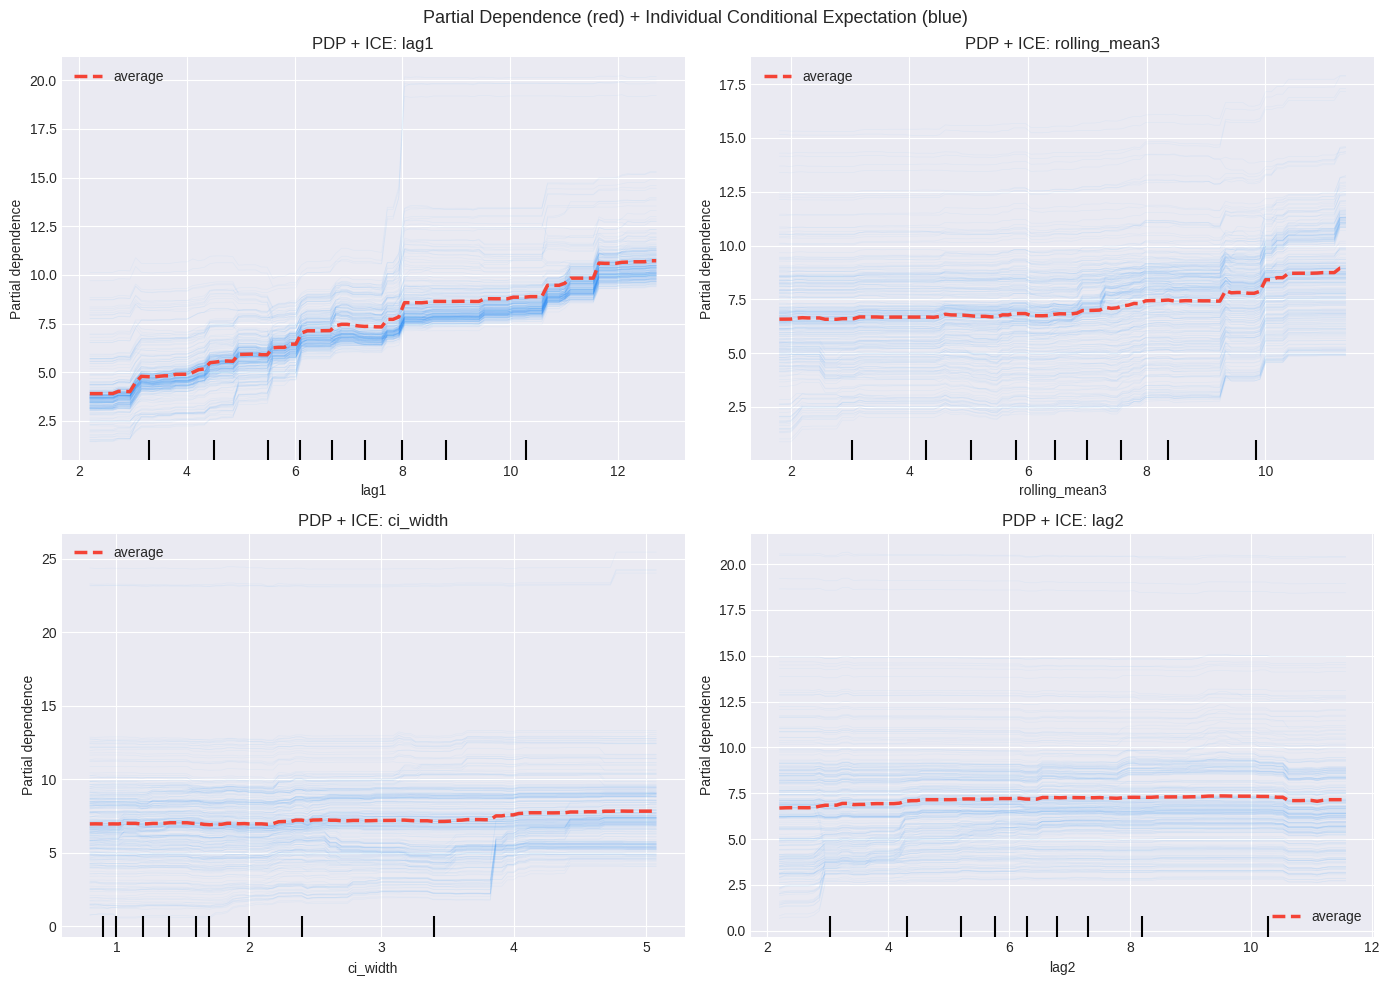

In [31]:
from sklearn.inspection import PartialDependenceDisplay

# PDP + ICE for the top 4 features
top_feat_indices = [FEATURES.index(f) for f in top_features]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, feat_idx, feat_name in zip(axes.flat, top_feat_indices, top_features):
    PartialDependenceDisplay.from_estimator(
        best['model'], X_test, [feat_idx],
        feature_names=FEATURES,
        kind='both',  # PDP + ICE
        ice_lines_kw={'color': '#2196F3', 'alpha': 0.05, 'linewidth': 0.5},
        pd_line_kw={'color': '#F44336', 'linewidth': 2.5},
        ax=ax
    )
    ax.set_title(f'PDP + ICE: {feat_name}')

plt.suptitle('Partial Dependence (red) + Individual Conditional Expectation (blue)', fontsize=13)
plt.tight_layout()
plt.show()

### 10.5 Decision Tree Visualization

Gradient Boosting and Random Forest are ensembles of many trees, so visualizing the full model
isn't feasible. Instead, we:
1. **Extract a single estimator** from the ensemble and plot its top levels
2. **Fit a shallow surrogate tree** (depth=4) on the full training data as an interpretable approximation

The surrogate tree shows the *approximate* decision logic the ensemble has learned in a human-readable form.

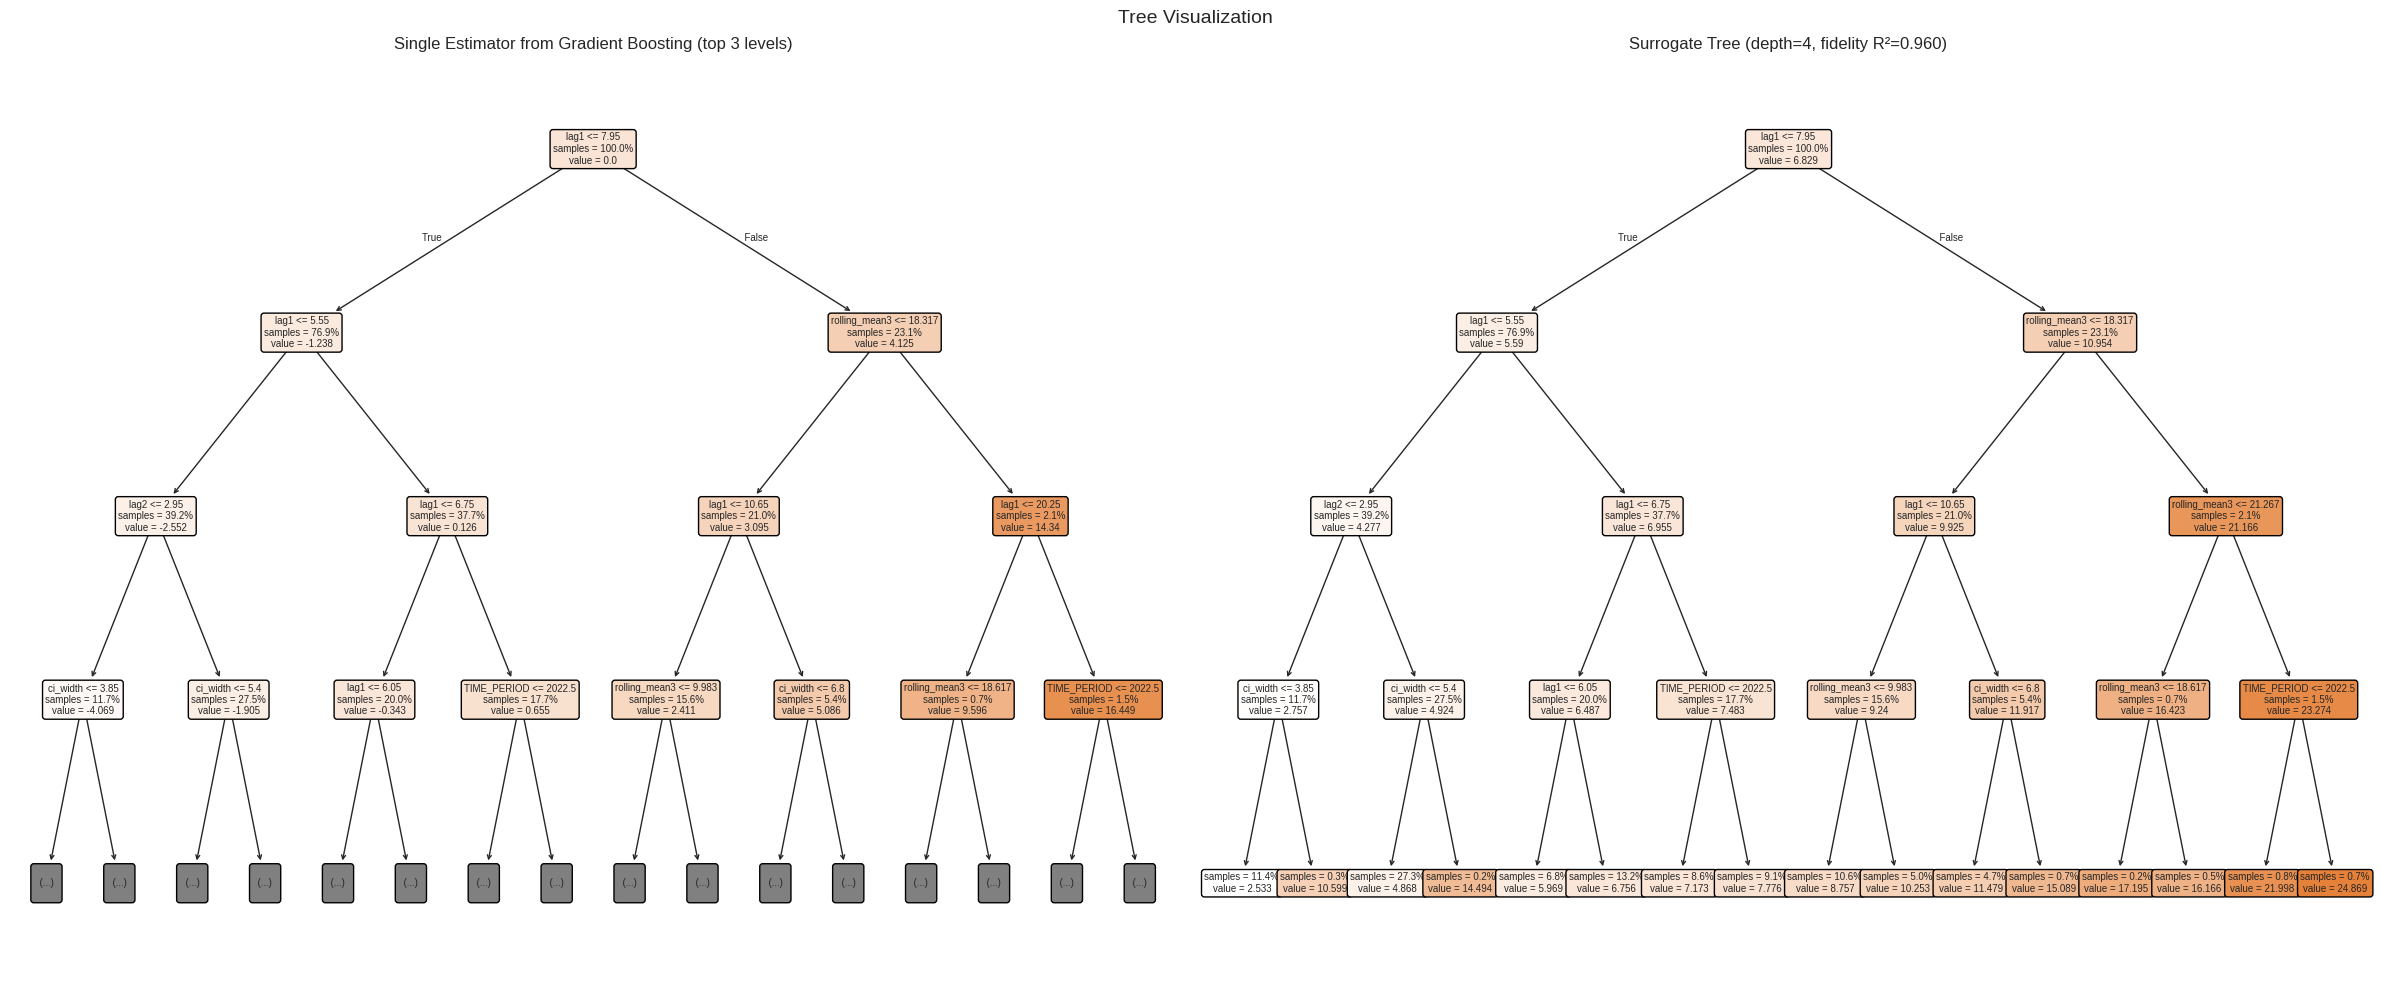


Surrogate tree fidelity (how well it approximates the ensemble): R²=0.9598
A high R² means the surrogate captures the ensemble's logic well.


In [32]:
from sklearn.tree import DecisionTreeRegressor, plot_tree

fig, axes = plt.subplots(1, 2, figsize=(24, 10))

# --- Panel 1: Single estimator from the ensemble ---
ax = axes[0]
if hasattr(best['model'], 'estimators_'):
    # GradientBoosting: estimators_ is 2D array [n_estimators, 1]
    if hasattr(best['model'].estimators_[0], '__len__'):
        single_tree = best['model'].estimators_[0][0]  # GB
    else:
        single_tree = best['model'].estimators_[0]      # RF

    plot_tree(
        single_tree, ax=ax,
        feature_names=FEATURES,
        filled=True, rounded=True,
        max_depth=3,
        fontsize=7,
        impurity=False,
        proportion=True,
    )
    ax.set_title(f'Single Estimator from {best_name} (top 3 levels)', fontsize=12)
else:
    ax.text(0.5, 0.5, 'Not a tree ensemble', ha='center', va='center', fontsize=14)
    ax.set_title('N/A (Ridge Regression)')

# --- Panel 2: Surrogate tree ---
ax = axes[1]
surrogate = DecisionTreeRegressor(max_depth=4, random_state=42)
surrogate.fit(X_train, best['model'].predict(X_train))  # fit to ensemble's predictions
surrogate_r2 = surrogate.score(X_test, best['predictions'])

plot_tree(
    surrogate, ax=ax,
    feature_names=FEATURES,
    filled=True, rounded=True,
    fontsize=7,
    impurity=False,
    proportion=True,
)
ax.set_title(f'Surrogate Tree (depth=4, fidelity R²={surrogate_r2:.3f})', fontsize=12)

plt.suptitle('Tree Visualization', fontsize=14)
plt.tight_layout()
plt.show()

print(f"\nSurrogate tree fidelity (how well it approximates the ensemble): R²={surrogate_r2:.4f}")
print("A high R² means the surrogate captures the ensemble's logic well.")

---
## 11. Phase 2 — Retrain on Full Data & Forecast 2025

Now that we've validated the model performs well on 2024, we retrain on **all available data (2019–2024)** and forecast 2025.

In [33]:
# Retrain best model type on 2019-2024
full_mask = df_feat['TIME_PERIOD'] <= 2024

X_full = df_feat.loc[full_mask, FEATURES].copy()
y_full = df_feat.loc[full_mask, TARGET]

assert np.isinf(X_full).sum().sum() == 0 and X_full.isna().sum().sum() == 0, "X_full has inf or NaN"
print(f"Full training data verified clean")

print(f"Full training set: {X_full.shape[0]} rows (all years with valid features)")

# Use same model class with slightly more capacity for the final model
if best_name == 'Random Forest':
    final_model = RandomForestRegressor(
        n_estimators=400, max_depth=14, random_state=42, n_jobs=-1
    )
elif best_name == 'Gradient Boosting':
    final_model = GradientBoostingRegressor(
        n_estimators=400, max_depth=6, learning_rate=0.05, random_state=42
    )
else:
    final_model = Ridge(alpha=1.0)

final_model.fit(X_full, y_full)
print(f"{best_name} retrained on 2019–2024 data")

Full training data verified clean
Full training set: 913 rows (all years with valid features)
Gradient Boosting retrained on 2019–2024 data


---
## 12. Construct 2025 Feature Vectors

To predict 2025, we need to build feature rows where:
- **lag1** = 2024 actual ESTIMATE (now known)
- **lag2** = 2023 actual ESTIMATE
- **rolling_mean3** = mean of 2022, 2023, 2024 actuals
- **diff1** = 2024 − 2023
- **ci_width** = 2024 CI width (best available proxy)

In [34]:
# Get 2024 and 2023 rows for building 2025 features
rows_2024 = df_feat.loc[df_feat['TIME_PERIOD'] == 2024].copy()
rows_2023 = df_feat.loc[df_feat['TIME_PERIOD'] == 2023].set_index(['TOPIC', 'SUBGROUP'])

forecast_rows = rows_2024.copy()
forecast_rows['TIME_PERIOD'] = 2025

# lag1 for 2025 = actual 2024 ESTIMATE
forecast_rows['lag1'] = rows_2024['ESTIMATE'].values

# lag2 for 2025 = actual 2023 ESTIMATE (which was lag1 in the 2024 row)
forecast_rows['lag2'] = rows_2024['lag1'].values

# rolling_mean3 for 2025 = mean of 2022, 2023, 2024 actuals
# 2024 actual = rows_2024['ESTIMATE'], 2023 = rows_2024['lag1'], 2022 = rows_2024['lag2']
forecast_rows['rolling_mean3'] = (
    rows_2024['ESTIMATE'].values +
    rows_2024['lag1'].values +
    rows_2024['lag2'].values
) / 3.0

# diff1 for 2025 = 2024 - 2023
forecast_rows['diff1'] = rows_2024['ESTIMATE'].values - rows_2024['lag1'].values

# ci_width stays from 2024 (best proxy)
# ci_width is already in forecast_rows from the copy

X_2025 = forecast_rows[FEATURES].copy()
X_2025.replace([np.inf, -np.inf], np.nan, inplace=True)  # convert inf to NaN so assertion catches both
assert X_2025.isna().sum().sum() == 0, f"2025 features have NaN: {X_2025.isna().sum()[X_2025.isna().sum() > 0].to_dict()}"
print("2025 forecast features verified clean")
print(f"2025 forecast rows: {X_2025.shape[0]}")
print(f"\nSample features for 2025:")
print(X_2025.head())

2025 forecast features verified clean
2025 forecast rows: 298

Sample features for 2025:
      TOPIC_encoded  GROUP_encoded  SUBGROUP_encoded  TIME_PERIOD  lag1  lag2  \
9365              0             18                 1         2025   8.6   7.2   
9371              0              0                 2         2025  10.7   8.7   
9377              0              0                 4         2025  10.8   9.0   
9383              0              0                 6         2025   9.5   7.8   
9389              0              0                 7         2025   2.6   2.5   

      rolling_mean3     diff1  ci_width  
9365       7.600000  1.400001       0.8  
9371       9.233334  2.000000       1.8  
9377       9.733333  1.800000       1.8  
9383       8.133333  1.700000       1.6  
9389       2.600000  0.100000       0.7  


In [44]:
# Predict 2025
pred_2025 = final_model.predict(X_2025)
forecast_rows['Predicted_2025'] = pred_2025

# Decode labels for readable output
forecast_results = forecast_rows[['TOPIC_encoded', 'SUBGROUP_encoded', 'ESTIMATE', 'Predicted_2025', 'ci_width']].copy()
forecast_results.rename(columns={'ESTIMATE': 'Actual_2024'}, inplace=True)
forecast_results['TOPIC'] = encoders['TOPIC'].inverse_transform(forecast_results['TOPIC_encoded'])
forecast_results['SUBGROUP'] = encoders['SUBGROUP'].inverse_transform(forecast_results['SUBGROUP_encoded'])
forecast_results.drop(columns=['TOPIC_encoded', 'SUBGROUP_encoded'], inplace=True)
forecast_results['Change_2024_to_2025'] = forecast_results['Predicted_2025'] - forecast_results['Actual_2024']

# Flag whether predicted change exceeds the subgroup's typical CI width
# If |change| < ci_width, the change is within measurement noise
forecast_results['CI_Width_2024'] = forecast_results['ci_width']
forecast_results['Exceeds_CI'] = forecast_results['Change_2024_to_2025'].abs() > forecast_results['CI_Width_2024']
forecast_results.drop(columns=['ci_width'], inplace=True)

print(f"2025 Predictions — Summary Statistics:")
print(f"  Mean predicted value: {pred_2025.mean():.2f}")
print(f"  Median predicted value: {np.median(pred_2025):.2f}")
print(f"  Range: [{pred_2025.min():.2f}, {pred_2025.max():.2f}]")
print(f"  Mean predicted change from 2024: {forecast_results['Change_2024_to_2025'].mean():.3f}")

n_exceeds = forecast_results['Exceeds_CI'].sum()
n_total = len(forecast_results)
print(f"\n  CI-based significance check:")
print(f"    {n_exceeds}/{n_total} ({n_exceeds/n_total*100:.0f}%) predicted changes exceed the subgroup's 2024 CI width")
print(f"    {n_total - n_exceeds}/{n_total} ({(n_total - n_exceeds)/n_total*100:.0f}%) predicted changes are within measurement noise")

2025 Predictions — Summary Statistics:
  Mean predicted value: 7.81
  Median predicted value: 7.76
  Range: [0.50, 28.10]
  Mean predicted change from 2024: 0.354

  CI-based significance check:
    2/298 (1%) predicted changes exceed the subgroup's 2024 CI width
    296/298 (99%) predicted changes are within measurement noise


In [47]:
# Display all predictions
forecast_results_sorted = forecast_results.sort_values(
    ['TOPIC', 'Change_2024_to_2025'], ascending=[True, False]
)
display_cols = ['TOPIC', 'SUBGROUP', 'Actual_2024', 'Predicted_2025',
                'Change_2024_to_2025', 'CI_Width_2024', 'Exceeds_CI']
print(forecast_results_sorted[display_cols].to_string(index=False))

                                                TOPIC                                    SUBGROUP  Actual_2024  Predicted_2025  Change_2024_to_2025  CI_Width_2024  Exceeds_CI
Delayed getting medical care due to cost among adults                   High social vulnerability     8.800000       10.111261             1.311261       1.400000       False
Delayed getting medical care due to cost among adults American Indian and Alaska Native and White    10.300000       11.596984             1.296984      11.400000       False
Delayed getting medical care due to cost among adults                                   Uninsured    26.799999       28.067180             1.267181       4.500000       False
Delayed getting medical care due to cost among adults                    Black only, non-Hispanic     8.700000        9.835665             1.135666       2.600000       False
Delayed getting medical care due to cost among adults                                   <100% FPL    11.500000       12.56345

---
## 14. Forecast Visualization

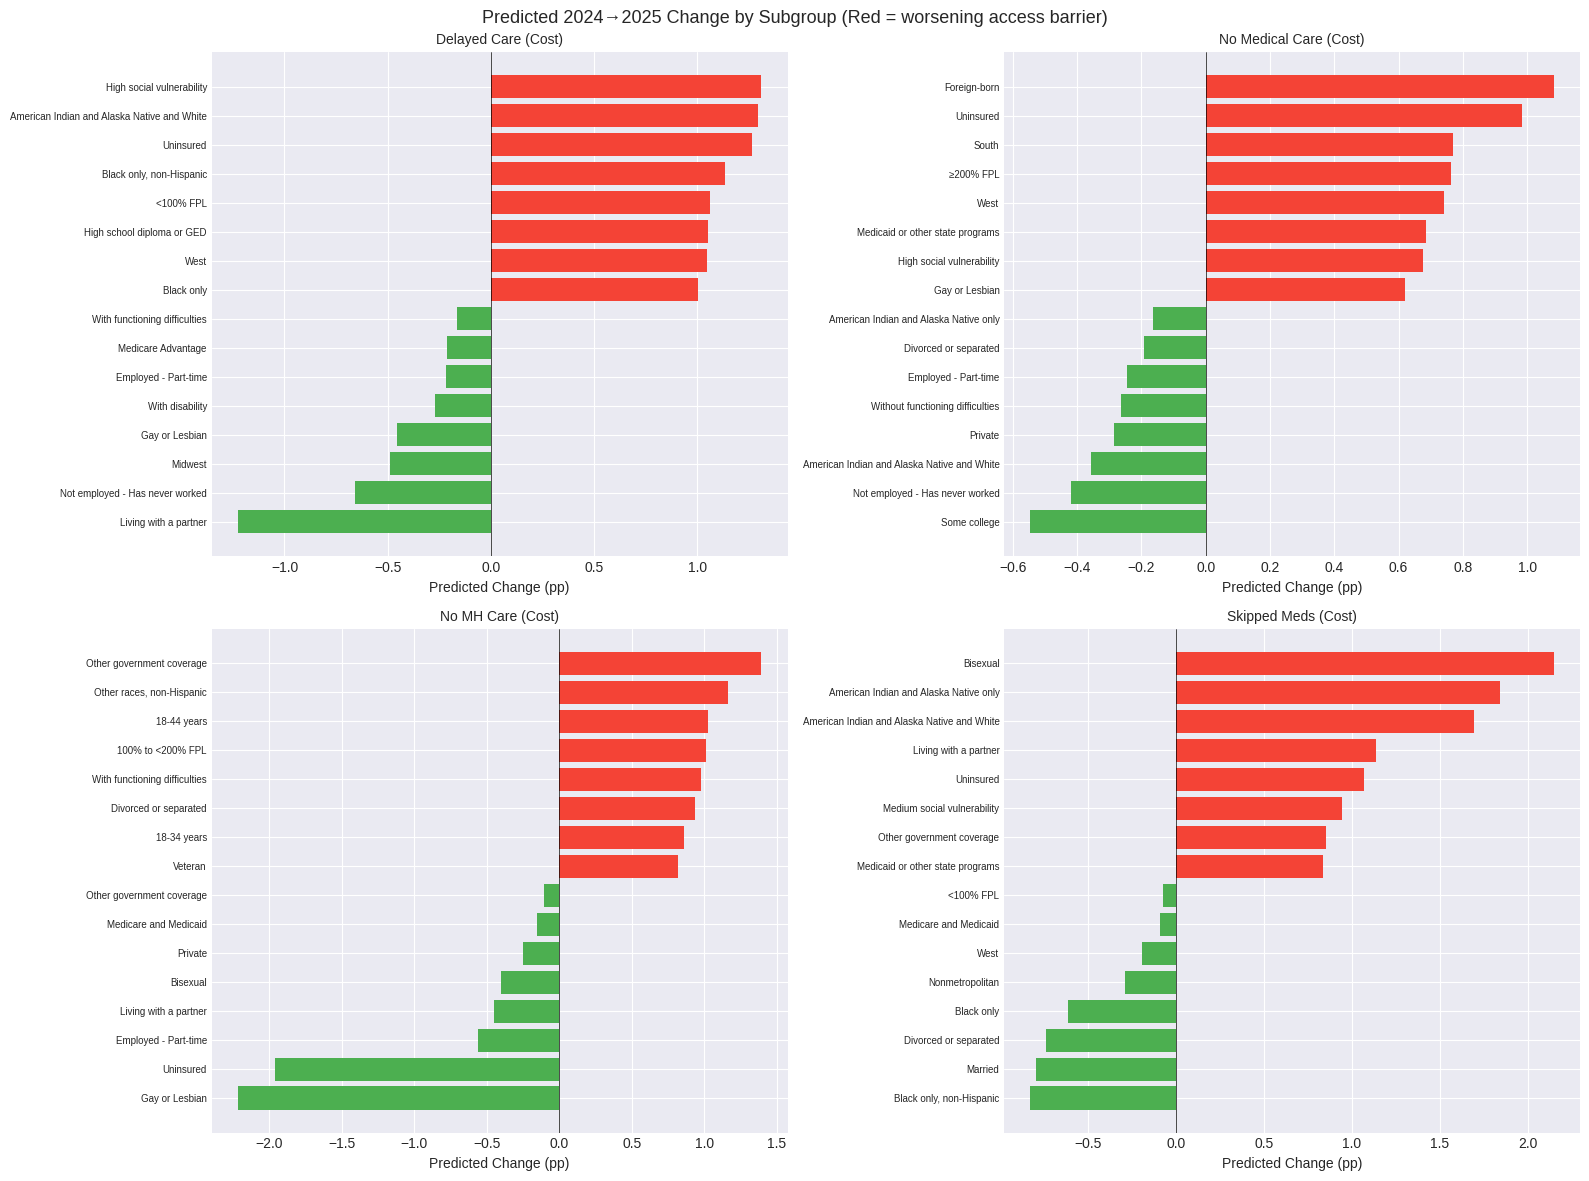

In [42]:
# Predicted change from 2024 to 2025 by topic
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

topics = forecast_results['TOPIC'].dropna().unique()
assert len(topics) > 0, "TOPIC column is all NaN — re-run from the prediction/decoding cell above"
assert all(isinstance(t, str) for t in topics), f"TOPIC values are not strings: {topics[:3]} — re-run from the prediction/decoding cell above"

for ax, topic in zip(axes.flat, topics):
    topic_data = forecast_results[forecast_results['TOPIC'] == topic].sort_values('Change_2024_to_2025')

    # Only show top/bottom movers if too many subgroups
    if len(topic_data) > 20:
        top_bottom = pd.concat([topic_data.head(8), topic_data.tail(8)])
    else:
        top_bottom = topic_data

    colors = ['#F44336' if x > 0 else '#4CAF50' for x in top_bottom['Change_2024_to_2025']]
    ax.barh(range(len(top_bottom)), top_bottom['Change_2024_to_2025'], color=colors)
    ax.set_yticks(range(len(top_bottom)))
    ax.set_yticklabels(top_bottom['SUBGROUP'], fontsize=7)
    ax.axvline(0, color='black', linewidth=0.5)
    ax.set_xlabel('Predicted Change (pp)')

    # Shorten title
    short = topic.replace('Delayed getting medical care due to cost among adults', 'Delayed Care (Cost)')
    short = short.replace('Did not get needed medical care due to cost', 'No Medical Care (Cost)')
    short = short.replace('Did not get needed mental health care due to cost', 'No MH Care (Cost)')
    short = short.replace('Did not take medication as prescribed to save money', 'Skipped Meds (Cost)')
    ax.set_title(short, fontsize=10)

plt.suptitle('Predicted 2024→2025 Change by Subgroup (Red = worsening access barrier)', fontsize=13)
plt.tight_layout()
plt.show()

In [48]:
# Top 10 subgroups with largest predicted worsening
print("\nTop 10 Subgroups Predicted to WORSEN (increasing barrier):")
worst = forecast_results_sorted.sort_values('Change_2024_to_2025', ascending=False).head(10)
print(worst[display_cols].to_string(index=False))

print("\nTop 10 Subgroups Predicted to IMPROVE (decreasing barrier):")
best_improve = forecast_results_sorted.sort_values('Change_2024_to_2025', ascending=True).head(10)
print(best_improve[display_cols].to_string(index=False))


Top 10 Subgroups Predicted to WORSEN (increasing barrier):
                                                TOPIC                                    SUBGROUP  Actual_2024  Predicted_2025  Change_2024_to_2025  CI_Width_2024  Exceeds_CI
  Did not take medication as prescribed to save money                                    Bisexual    19.700001       21.847217             2.147216       8.200001       False
  Did not take medication as prescribed to save money      American Indian and Alaska Native only     8.300000       10.142282             1.842282       9.300000       False
  Did not take medication as prescribed to save money American Indian and Alaska Native and White     6.200000        7.895007             1.695007       7.400001       False
    Did not get needed mental health care due to cost                   Other government coverage     5.700000        7.093144             1.393145       3.700000       False
Delayed getting medical care due to cost among adults            